### Первый тестовый запуск

In [19]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from src.pipeline import run_pipeline
from src.embedding import predict_mask
from src.metrics import show_clusters

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

terms = ["fam"]

all_results = []

for term in terms:
    df = pd.read_csv(f"data/{term}_annotation.csv")

    res_kmeans = run_pipeline(df, tokenizer, model, device, method="kmeans")
    res_agglo = run_pipeline(df, tokenizer, model, device, method="agglo")

    res_kmeans_k3 = run_pipeline(df, tokenizer, model, device,
                            method="kmeans", k_mode="forced", forced_k=3)

    res_agglo_k3 = run_pipeline(df, tokenizer, model, device,
                           method="agglo", k_mode="forced", forced_k=3)

    print(res_kmeans)
    print(res_agglo)
    print(res_kmeans_k3)
    print(res_agglo_k3)

c:\Users\Таня\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


{'metrics': {'term': 'fam', 'setting': 'auto_k', 'k': 2, 'silhouette': 0.17688100039958954, 'pairwise_precision': 0.371976647206005, 'pairwise_recall': 0.6545988258317026, 'pairwise_f1': 0.4743839744726112, 'ARI': 0.01123011543461327, 'NMI': 0.004080335433810836, 'purity': 0.49056603773584906}, 'labels': array([1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0]), 'texts': ['happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday', 'next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun', 'thank you friends [MASK] for all the happy birthd

### Второй итоговый запуск

In [20]:
from collections import Counter
import torch
import torch.nn.functional as F

def cluster_synonyms_freq(texts, term, tokenizer, mlm_model, device, top_k=5):
    all_preds = []

    for text in texts:
        if term not in text:
            continue

        masked = text.replace(term, "[MASK]")
        preds = predict_mask(tokenizer, mlm_model, masked, device)

        all_preds.extend(preds)
    all_preds = [p for p in all_preds if p not in STOPWORDS]
    counter = Counter(all_preds)

    return counter.most_common(top_k)


def cluster_synonyms_logits(texts, term, tokenizer, mlm_model, device, top_k=5):

    mlm_model.eval()
    sum_logits = None
    count = 0

    for text in texts:
        if term not in text:
            continue

        masked = text.replace(term, "[MASK]")
        inputs = tokenizer(masked, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = mlm_model(**inputs)

        mask_positions = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)

        if len(mask_positions[0]) == 0:
            continue

        mask_idx = mask_positions[1][0]

        logits = outputs.logits[0, mask_idx, :]  # [vocab]

        if sum_logits is None:
            sum_logits = logits
        else:
            sum_logits += logits

        count += 1

    if count == 0:
        return []

    avg_logits = sum_logits / count
    probs = F.softmax(avg_logits, dim=-1)

    top_ids = torch.topk(probs, top_k).indices.tolist()
    
    tokens = [tokenizer.decode([i]).strip() for i in top_ids]
    tokens = [t for t in tokens if t not in STOPWORDS]
    return tokens

In [21]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from transformers import AutoModelForMaskedLM

from src.pipeline import run_pipeline
from src.embedding import predict_mask
from src.metrics import show_clusters, show_mismatches
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(res, title="Confusion Matrix"):
    """
    Строит матрицу ошибок для результатов кластеризации.
    res: словарь от run_pipeline (с ключами 'labels' и 'gold')
    """
    y_pred = res['labels']
    y_true = res['gold']
    
    # Создаём кросс-таблицу: строки – предсказанные кластеры, столбцы – золотые смыслы
    df = pd.DataFrame({'predicted_cluster': y_pred, 'gold_sense': y_true})
    cm = pd.crosstab(df['predicted_cluster'], df['gold_sense'], dropna=False)
    
    # Убеждаемся, что все золотые смыслы присутствуют в столбцах (добавляем недостающие с нулями)
    unique_gold = sorted(set(y_true))
    for gold in unique_gold:
        if gold not in cm.columns:
            cm[gold] = 0
    cm = cm[unique_gold]  # фиксируем порядок столбцов
    
    # Рисуем тепловую карту
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title(title)
    plt.xlabel("Gold senses")
    plt.ylabel("Predicted clusters")
    plt.tight_layout()
    plt.show()
    
    # Доминирующий смысл для каждого кластера
    dominant = cm.idxmax(axis=1).to_dict()
    print("Dominant gold sense per cluster:", dominant)
    return cm, dominant


In [23]:
def plot_tsne(X, labels):

    tsne = TSNE(n_components=2, random_state=42)
    X_2d = tsne.fit_transform(X)

    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels)
    plt.title("t-SNE visualization of clusters")
    plt.show()

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

encoder_model = AutoModel.from_pretrained("bert-base-uncased")
mlm_model = AutoModelForMaskedLM.from_pretrained("bert-base-uncased")

STOPWORDS = set([",", ".", "!", "-", "'", "and", "the", "a", "of", "to"])

terms = ["fam"]

all_results = []

c:\Users\Таня\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model)

In [25]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_with_shapes(X, pred_labels, gold_labels, title="t-SNE visualization"):
    """
    X: матрица эмбеддингов (n_samples, n_features)
    pred_labels: предсказанные кластеры (например, от k-means)
    gold_labels: золотые метки (например, bio, social, vocative)
    """
    # 1. Уменьшаем размерность до 2D с помощью t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X)

    # 2. Назначаем цвет в зависимости от предсказанного кластера
    unique_pred = sorted(set(pred_labels))
    colors = plt.cm.Set2.colors  # палитра, устойчивая к дальтонизму

    # 3. Назначаем форму маркера в зависимости от золотой метки
    #    Преобразуем золотые метки в числовые коды или используем словарь
    gold_unique = sorted(set(gold_labels))
    marker_map = {label: marker for label, marker in zip(gold_unique, ['o', 's', '^', 'D', 'v', 'p'])}
    # 'o' - круг, 's' - квадрат, '^' - треугольник, 'D' - ромб и т.д.

    # 4. Строим график
    plt.figure(figsize=(10, 7))
    for pred_cls in unique_pred:
        # Выбираем точки, принадлежащие данному предсказанному кластеру
        idx_pred = [i for i, p in enumerate(pred_labels) if p == pred_cls]
        for gold_cls in gold_unique:
            # Пересечение: точки с данным предсказанным кластером И данной золотой меткой
            idx_gold = [i for i in idx_pred if gold_labels[i] == gold_cls]
            if not idx_gold:
                continue
            X_sub = X_tsne[idx_gold]
            plt.scatter(
                X_sub[:, 0], X_sub[:, 1],
                color=colors[pred_cls % len(colors)],
                marker=marker_map[gold_cls],
                label=f"pred={pred_cls}, gold={gold_cls}",
                alpha=0.7,
                edgecolors='k',
                s=80
            )

    # Убираем дублирование легенды
    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    plt.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

term: fam

 random | mask | fixed


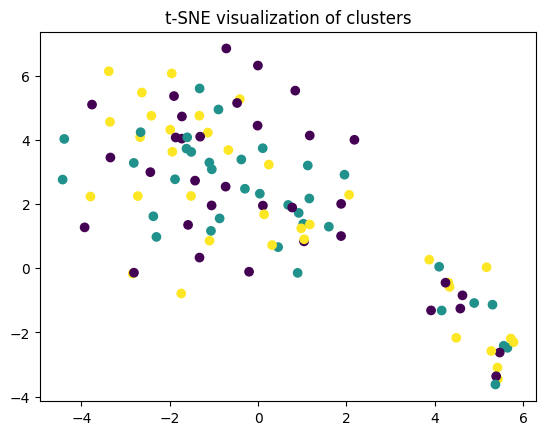

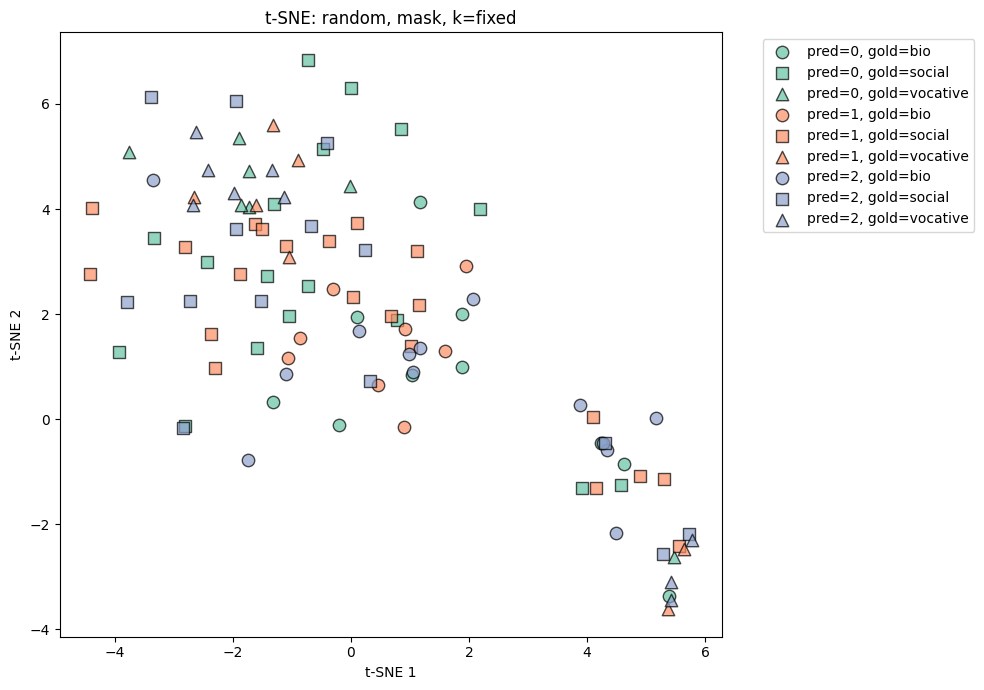


 misclassified examples

text: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
gold: social pred: 2

text: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
gold: bio pred: 0

text: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
gold: bio pred: 2

text: dim sum with the [MASK]
gold: bio pred: 2

text: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
gold: bio pred: 0

text: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space with you 

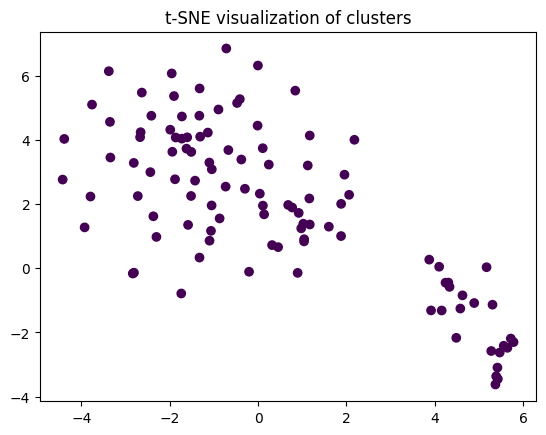

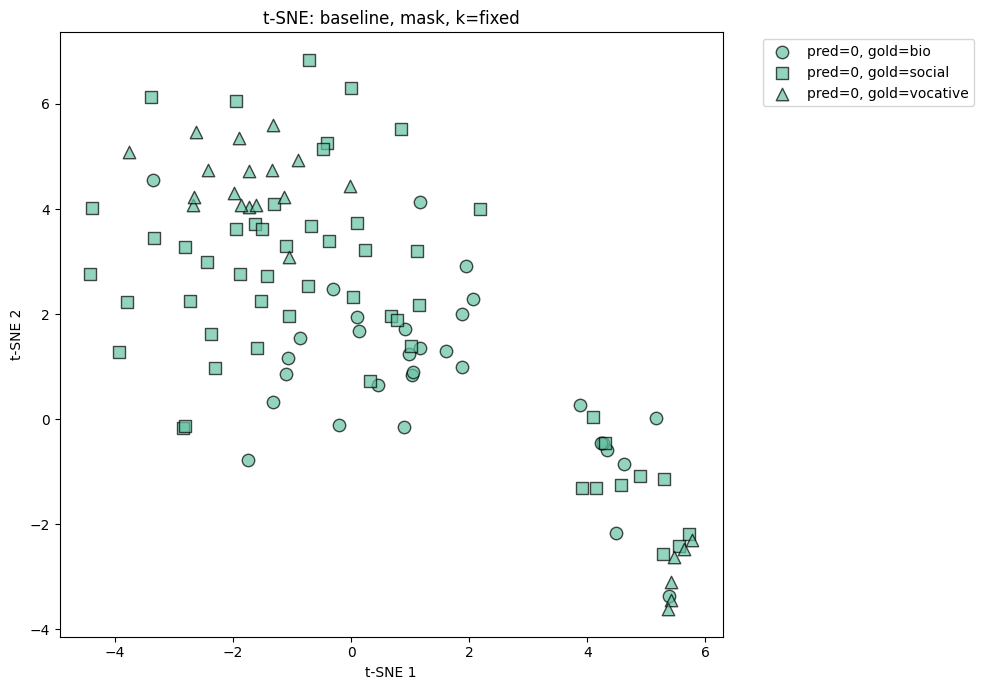


 misclassified examples

text: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
gold: social pred: 0

text: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
gold: bio pred: 0

text: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
gold: bio pred: 0

text: dim sum with the [MASK]
gold: bio pred: 0

text: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
gold: bio pred: 0

text: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space with you 

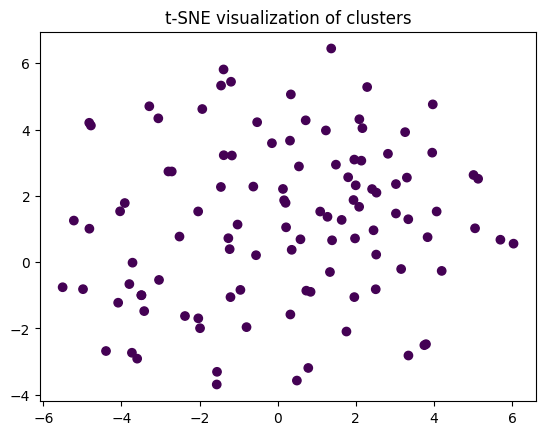

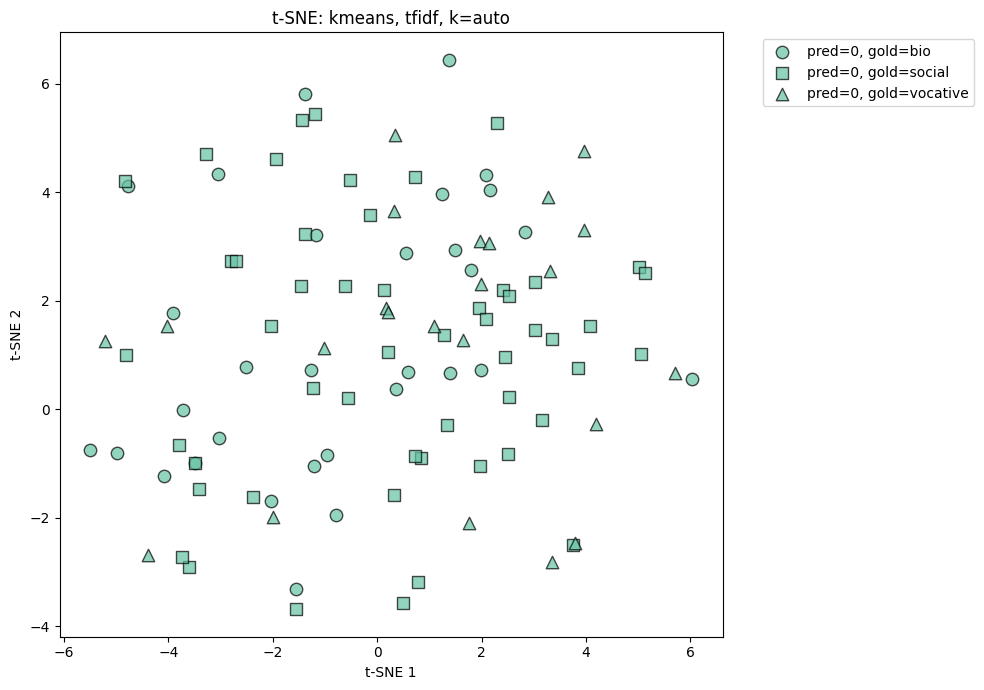


 misclassified examples

text: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
gold: social pred: 0

text: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
gold: bio pred: 0

text: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
gold: bio pred: 0

text: dim sum with the [MASK]
gold: bio pred: 0

text: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
gold: bio pred: 0

text: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space with you 

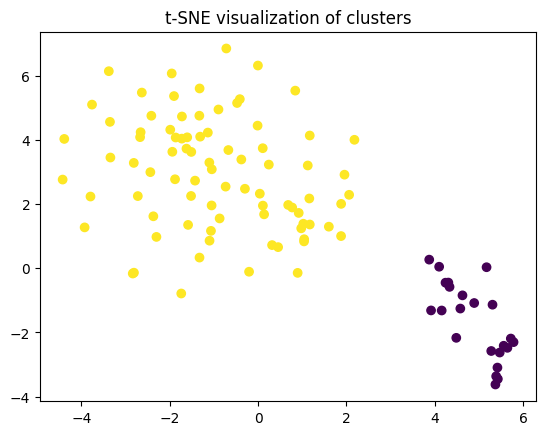

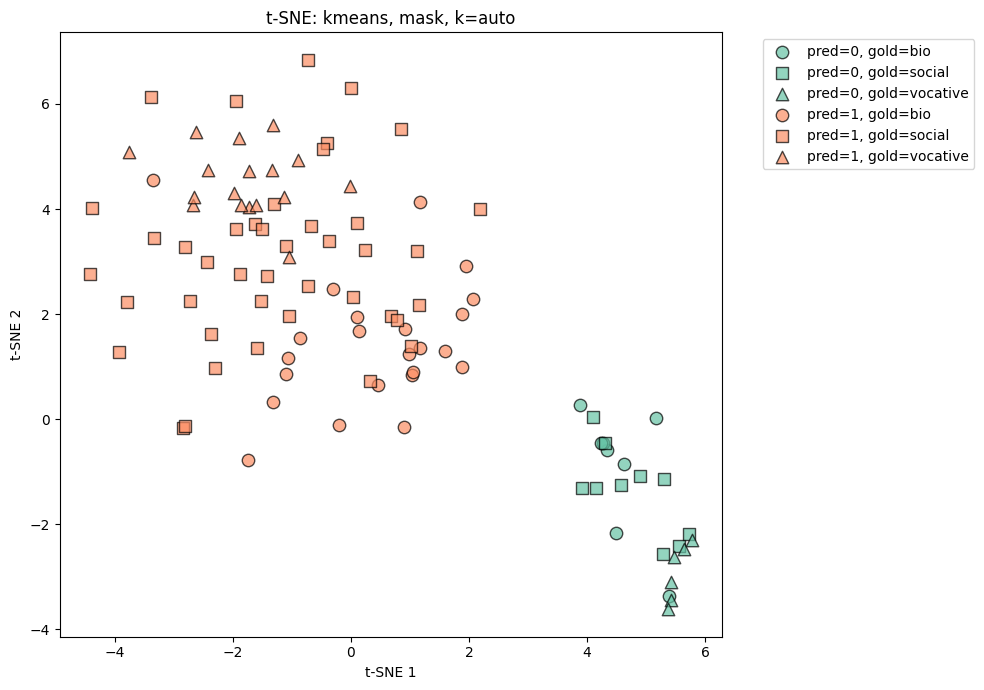


 misclassified examples

text: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
gold: social pred: 1

text: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
gold: bio pred: 1

text: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
gold: bio pred: 1

text: dim sum with the [MASK]
gold: bio pred: 0

text: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
gold: bio pred: 0

text: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space with you 

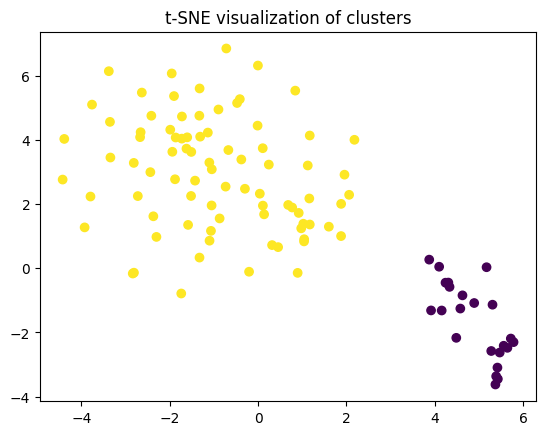

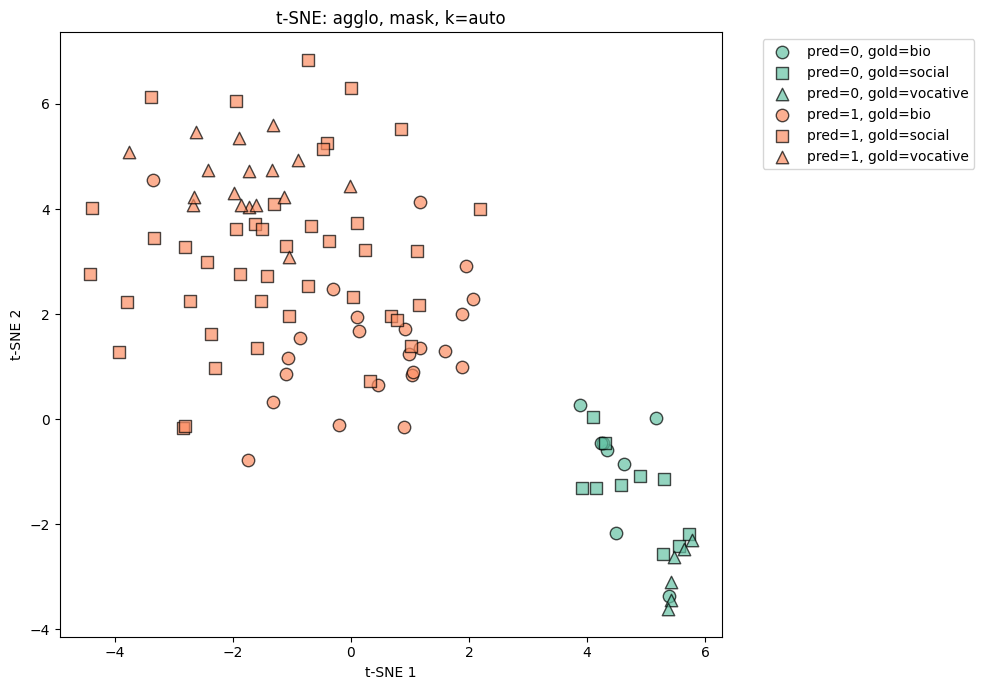


 misclassified examples

text: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
gold: social pred: 1

text: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
gold: bio pred: 1

text: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
gold: bio pred: 1

text: dim sum with the [MASK]
gold: bio pred: 0

text: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
gold: bio pred: 0

text: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space with you 

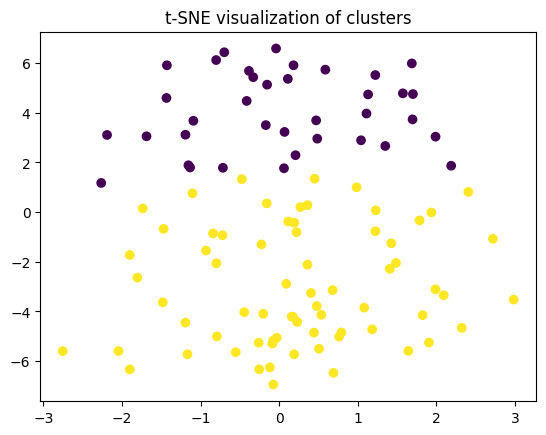

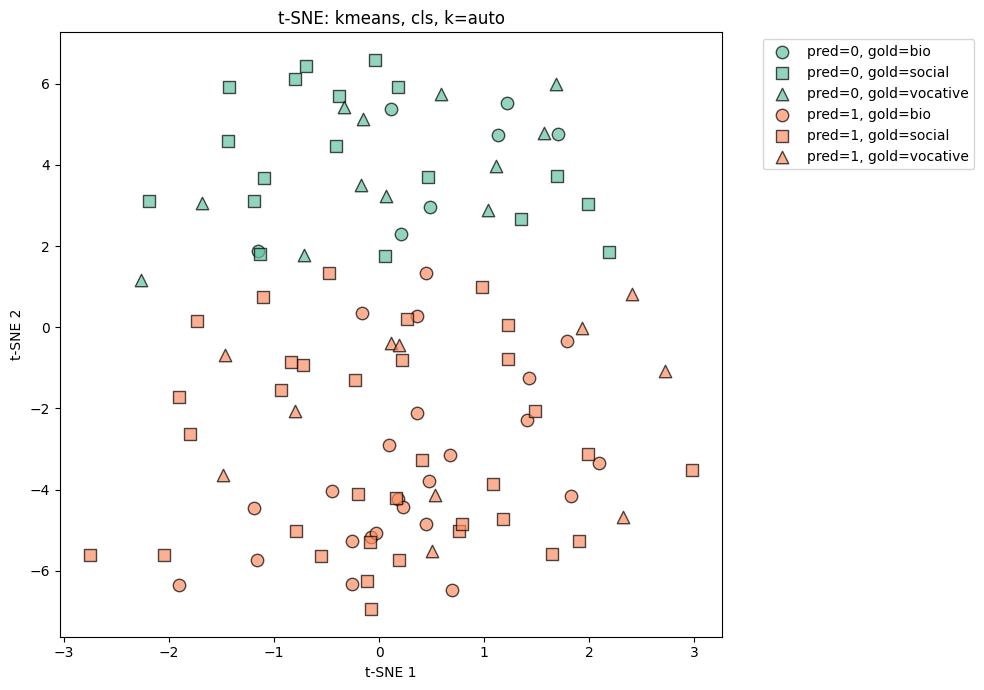


 misclassified examples

text: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
gold: social pred: 1

text: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
gold: bio pred: 1

text: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
gold: bio pred: 1

text: dim sum with the [MASK]
gold: bio pred: 1

text: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
gold: bio pred: 1

text: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space with you 

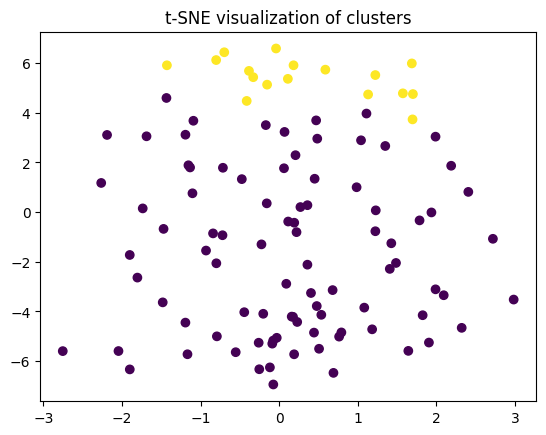

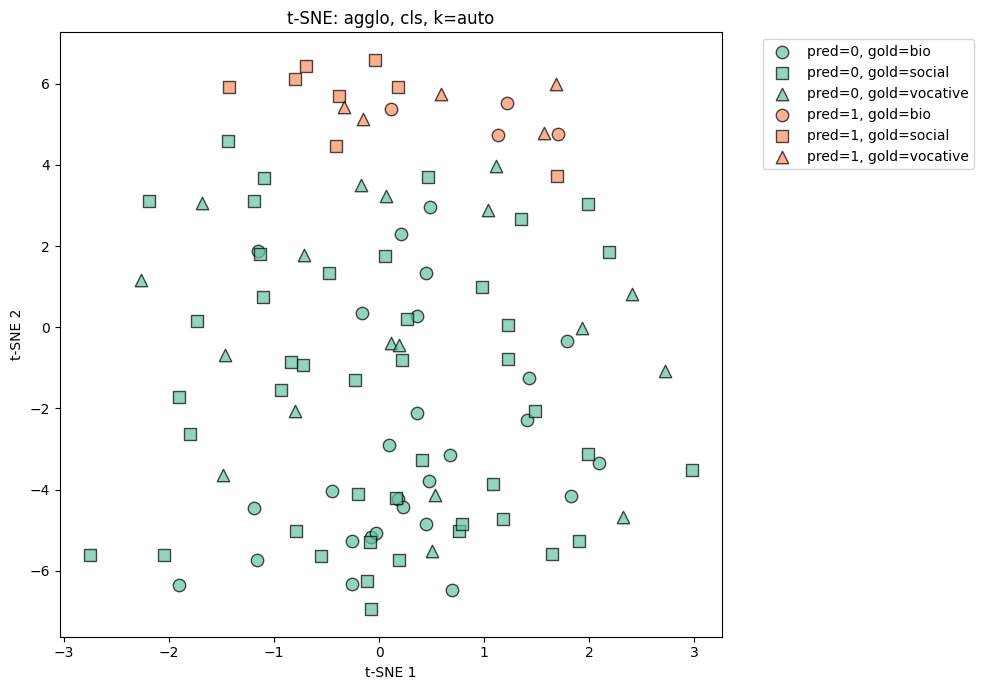


 misclassified examples

text: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
gold: social pred: 0

text: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
gold: bio pred: 0

text: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
gold: bio pred: 0

text: dim sum with the [MASK]
gold: bio pred: 0

text: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
gold: bio pred: 0

text: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space with you 

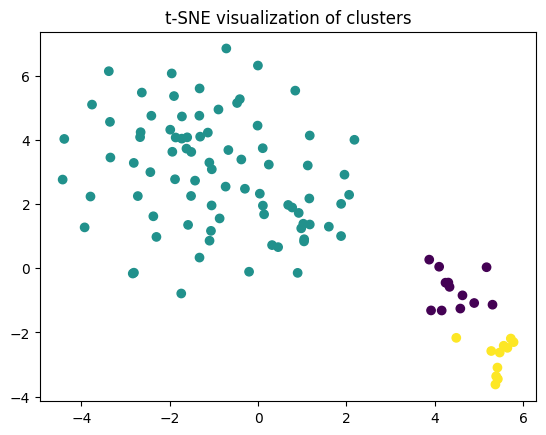

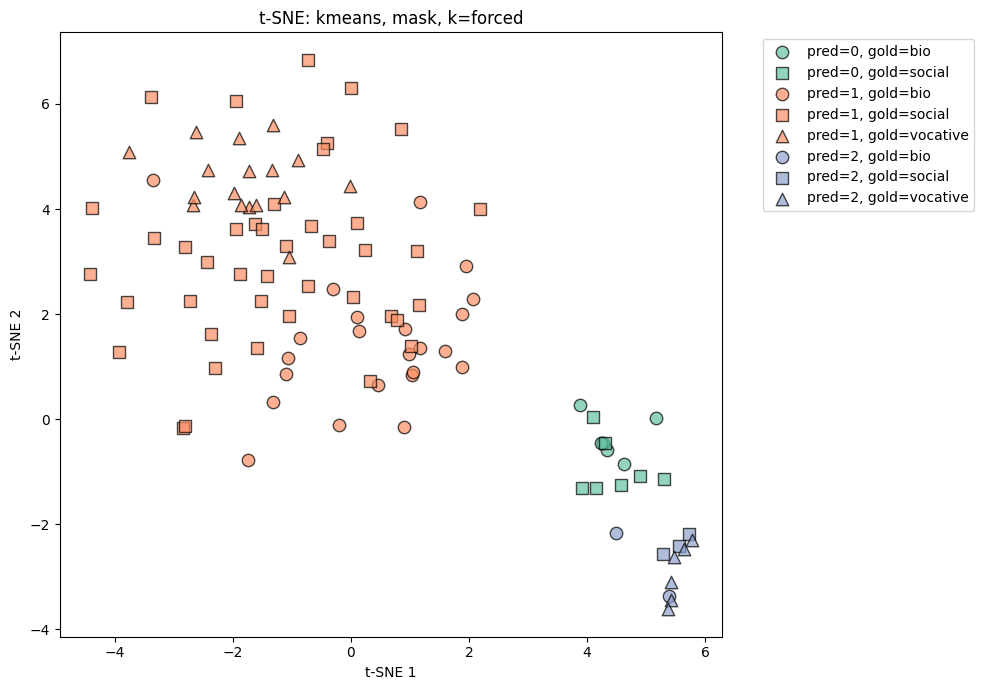


 misclassified examples

text: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
gold: social pred: 1

text: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
gold: bio pred: 1

text: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
gold: bio pred: 1

text: dim sum with the [MASK]
gold: bio pred: 0

text: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
gold: bio pred: 0

text: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space with you 

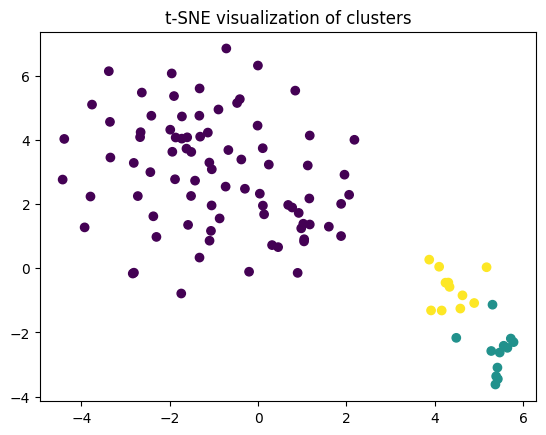

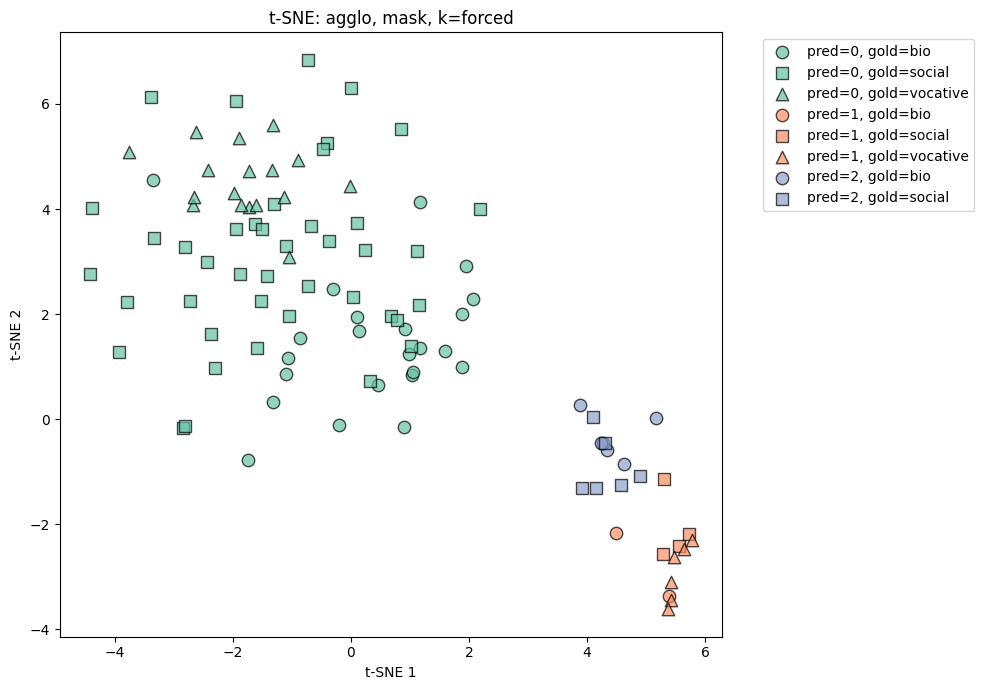


 misclassified examples

text: happy th to the og bro it is been a minute years and counting bro pleasure is all mine and mad love blessed to call you my brother my [MASK] my g happy birthday
gold: social pred: 0

text: next week with my [MASK] at introducing for his first time in london the bro from paris this is going to be fun
gold: bio pred: 0

text: thank you friends [MASK] for all the happy birthday messages today so nice to hear from you all i thought you would all forgotten me haha had a great day with my family our new puppy and my incredibly loving fiance x
gold: bio pred: 0

text: dim sum with the [MASK]
gold: bio pred: 2

text: sunday vibes courtesy of it cannot all be work and chaos sometimes it has to be crepes as big as your face and lounging and lego and ironing my sunday with the [MASK]
gold: bio pred: 2

text: i went to peckham last night walked in at am had the best time [MASK] you guys are everything so glad i caught this moment amazing to share the space with you 

KeyError: 'original_texts'

In [ ]:

terms = ["fam"]

all_results = []

for term in terms:
    print("term:", term)

    df = pd.read_csv(f"data/{term}_annotation.csv")

    configs = [
    # RANDOM BASELINE
    ("random", "mask", "fixed", 3),

    # SIMPLE BASELINE (1 cluster)
    ("baseline", "mask", "fixed", 1),

    # TF-IDF baseline (НОВЫЙ)
    ("kmeans", "tfidf", "auto", None),

    # MAIN MODELS
    ("kmeans", "mask", "auto", None),
    ("agglo", "mask", "auto", None),

    ("kmeans", "cls", "auto", None),
    ("agglo", "cls", "auto", None),

    # FIXED K
    ("kmeans", "mask", "forced", 3),
    ("agglo", "mask", "forced", 3),
]

    for method, emb, k_mode, k in configs:

        print(f"\n {method} | {emb} | {k_mode}")

        res = run_pipeline(
            df,
            tokenizer,
            encoder_model,
            device,
            method=method,
            embedding_type=emb,
            k_mode=k_mode,
            forced_k=k
        )
        plot_confusion_matrix(res, title=f"{term} - {method} {emb} {k_mode}")
        plot_tsne(res["X"], res["labels"])

        plot_tsne_with_shapes(
            X=res["X"],
            pred_labels=res["labels"],
            gold_labels=res["gold"],
            title=f"t-SNE: {method}, {emb}, k={k_mode}"
        )

        show_mismatches(
            res["texts"],
            res["gold"],
            res["labels"]
        )

        print(res["metrics"])

        row = res["metrics"].copy()
        row["method"] = method
        row["embedding"] = emb
        all_results.append(row)


        if method in ["kmeans", "agglo", "hybrid"]:
            show_clusters(
                res["texts"],
                res["labels"],
                res["gold"]
            )


    print("\n CLUSTER-LEVEL SYNONYMS")

    clusters = {}
    for text, label in zip(res["original_texts"], res["labels"]):
        clusters.setdefault(label, []).append(text)

    for cluster_id, texts_cluster in clusters.items():
        freq_syns = cluster_synonyms_freq(texts_cluster, term, tokenizer, mlm_model, device)
        logit_syns = cluster_synonyms_logits(texts_cluster, term, tokenizer, mlm_model, device)

        print("Logits:", logit_syns)


df_results = pd.DataFrame(all_results)
df_results.to_csv("results/results.csv", index=False)

print("\n final results:")
print(df_results)

term: manifest

 random | mask | fixed


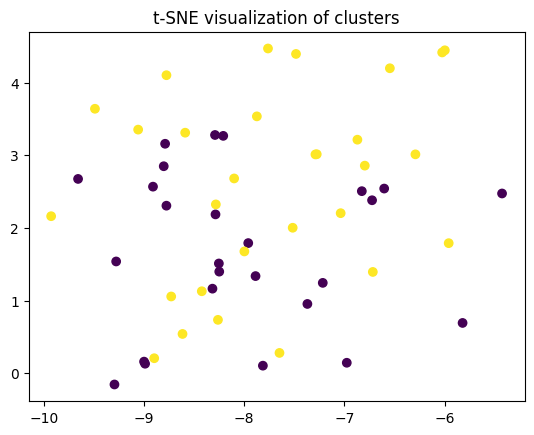

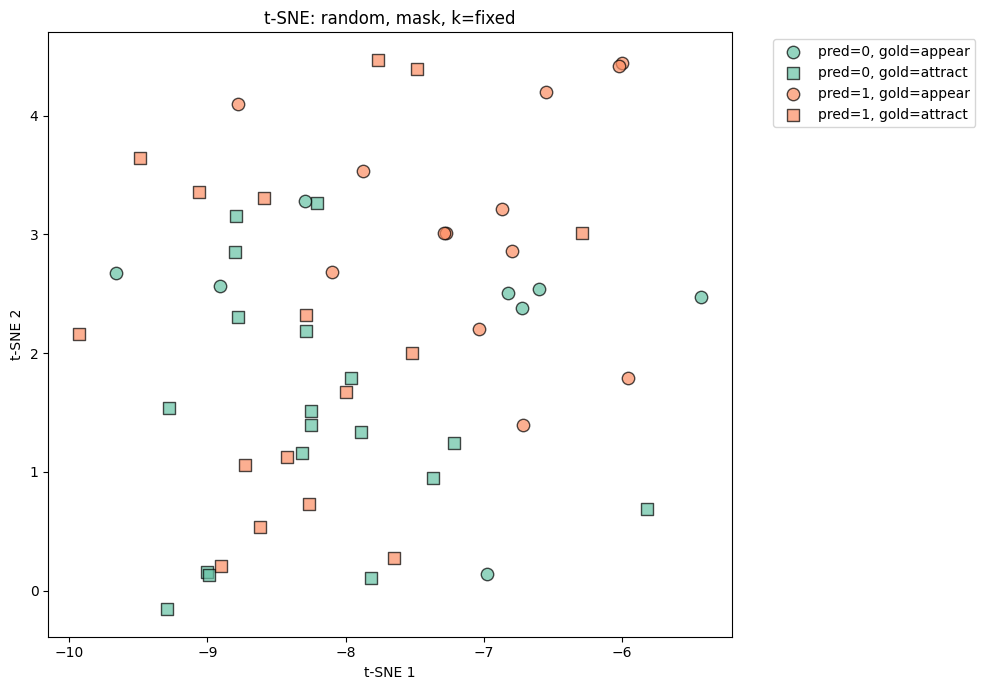


 misclassified examples

text: saturday th jan yep is going to be laying down some funky ukg dubs to [MASK] power and success in your come down to the basement for an afternoon seminar with incognito radio and friends oh yeah will be providing the food you all
gold: attract pred: 0

text: the tube map of yor mind the map is not the territory i went to an illuminating talk by advertising guru and behavioural science expert rory sutherland today one highlight amongst many was his use of the london tube map to illustrate the mental maps we all create in our minds as means for navigating and understanding the world just like the london tube map our mental maps contain distortions all based on the way we laid down and encoded them experience after experience and from a psychology perspective these distortions are [MASK] as cognitive biases and heuristics now rory was highlighting how problems can arise when we are all begin to use the same maps what i took from this was how societal influe

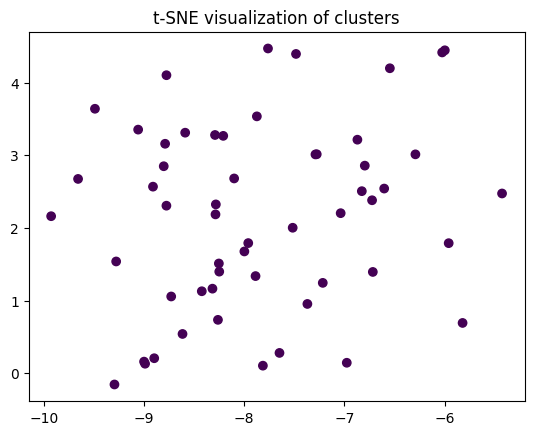

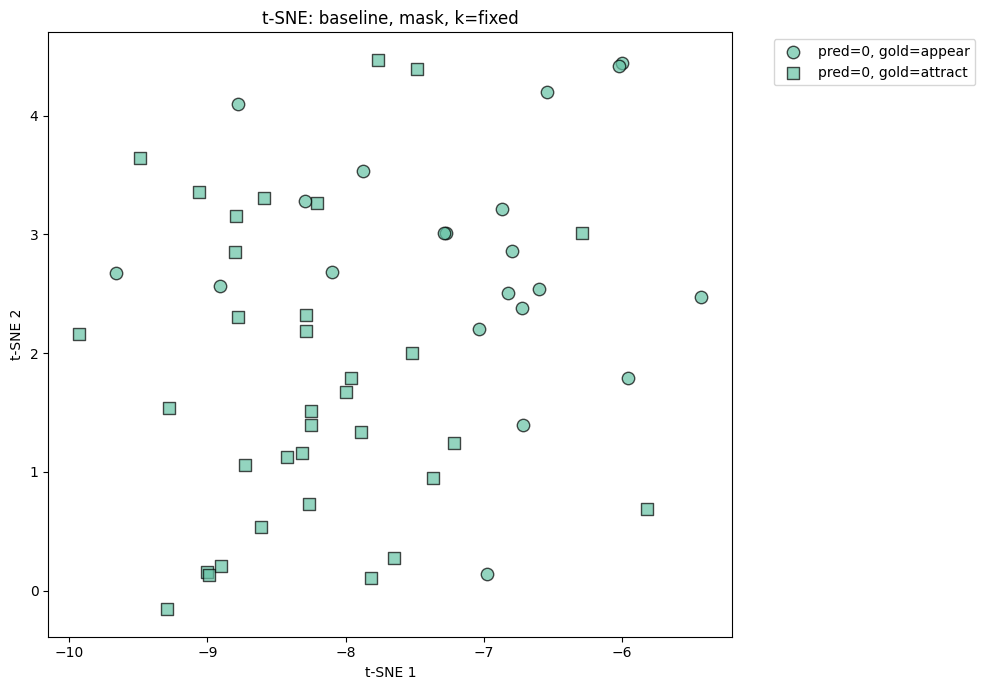


 misclassified examples

text: saturday th jan yep is going to be laying down some funky ukg dubs to [MASK] power and success in your come down to the basement for an afternoon seminar with incognito radio and friends oh yeah will be providing the food you all
gold: attract pred: 0

text: the tube map of yor mind the map is not the territory i went to an illuminating talk by advertising guru and behavioural science expert rory sutherland today one highlight amongst many was his use of the london tube map to illustrate the mental maps we all create in our minds as means for navigating and understanding the world just like the london tube map our mental maps contain distortions all based on the way we laid down and encoded them experience after experience and from a psychology perspective these distortions are [MASK] as cognitive biases and heuristics now rory was highlighting how problems can arise when we are all begin to use the same maps what i took from this was how societal influe

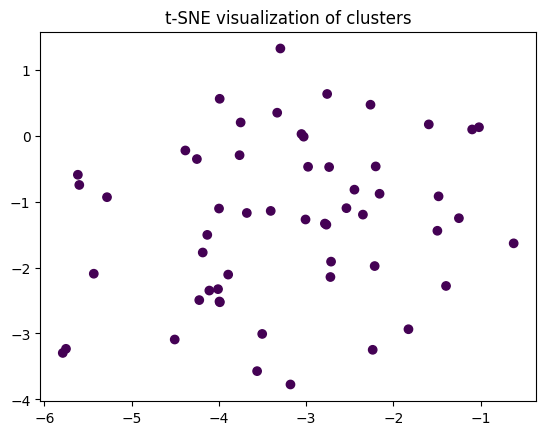

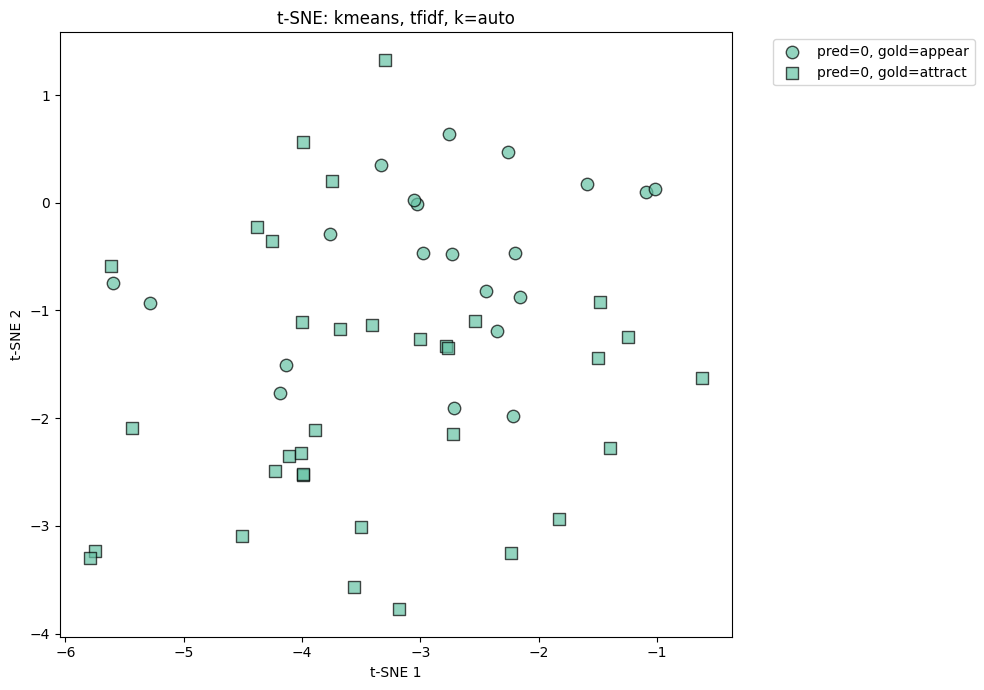


 misclassified examples

text: saturday th jan yep is going to be laying down some funky ukg dubs to [MASK] power and success in your come down to the basement for an afternoon seminar with incognito radio and friends oh yeah will be providing the food you all
gold: attract pred: 0

text: the tube map of yor mind the map is not the territory i went to an illuminating talk by advertising guru and behavioural science expert rory sutherland today one highlight amongst many was his use of the london tube map to illustrate the mental maps we all create in our minds as means for navigating and understanding the world just like the london tube map our mental maps contain distortions all based on the way we laid down and encoded them experience after experience and from a psychology perspective these distortions are [MASK] as cognitive biases and heuristics now rory was highlighting how problems can arise when we are all begin to use the same maps what i took from this was how societal influe

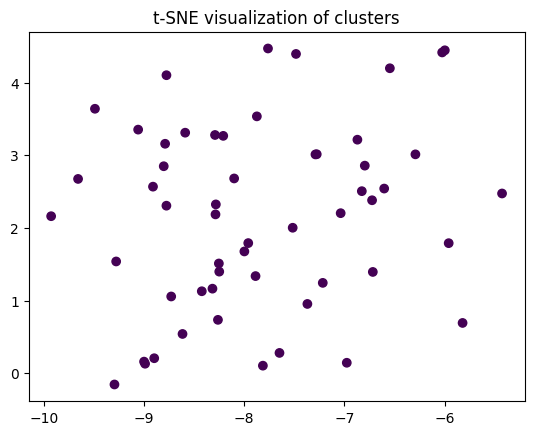

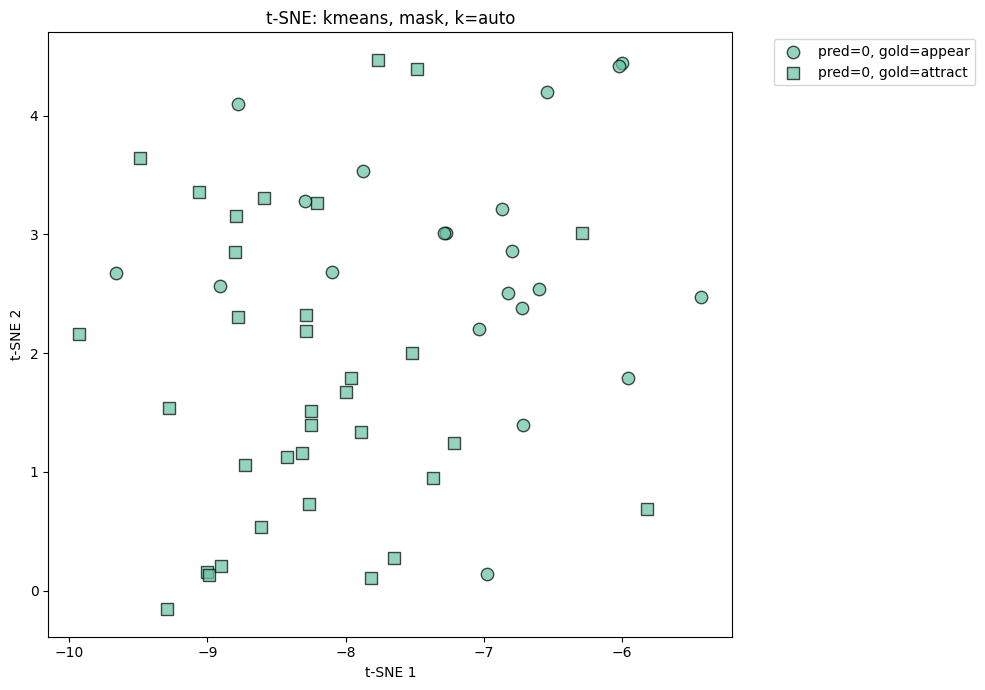


 misclassified examples

text: saturday th jan yep is going to be laying down some funky ukg dubs to [MASK] power and success in your come down to the basement for an afternoon seminar with incognito radio and friends oh yeah will be providing the food you all
gold: attract pred: 0

text: the tube map of yor mind the map is not the territory i went to an illuminating talk by advertising guru and behavioural science expert rory sutherland today one highlight amongst many was his use of the london tube map to illustrate the mental maps we all create in our minds as means for navigating and understanding the world just like the london tube map our mental maps contain distortions all based on the way we laid down and encoded them experience after experience and from a psychology perspective these distortions are [MASK] as cognitive biases and heuristics now rory was highlighting how problems can arise when we are all begin to use the same maps what i took from this was how societal influe

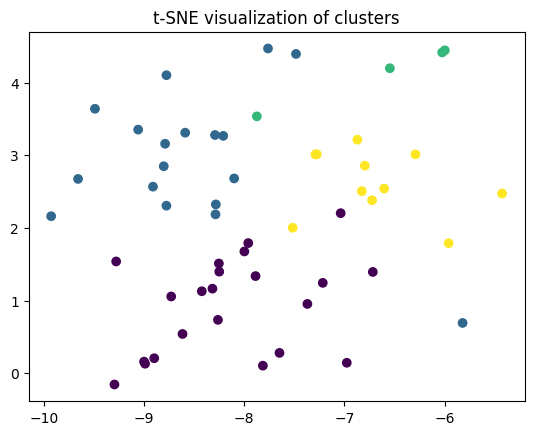

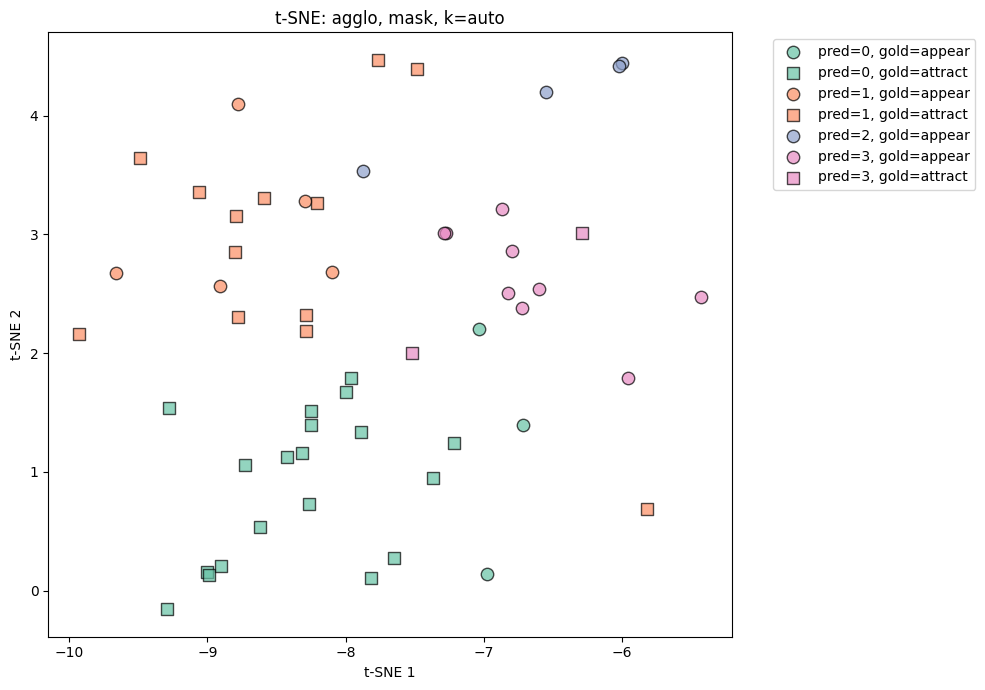


 misclassified examples

text: saturday th jan yep is going to be laying down some funky ukg dubs to [MASK] power and success in your come down to the basement for an afternoon seminar with incognito radio and friends oh yeah will be providing the food you all
gold: attract pred: 0

text: the tube map of yor mind the map is not the territory i went to an illuminating talk by advertising guru and behavioural science expert rory sutherland today one highlight amongst many was his use of the london tube map to illustrate the mental maps we all create in our minds as means for navigating and understanding the world just like the london tube map our mental maps contain distortions all based on the way we laid down and encoded them experience after experience and from a psychology perspective these distortions are [MASK] as cognitive biases and heuristics now rory was highlighting how problems can arise when we are all begin to use the same maps what i took from this was how societal influe

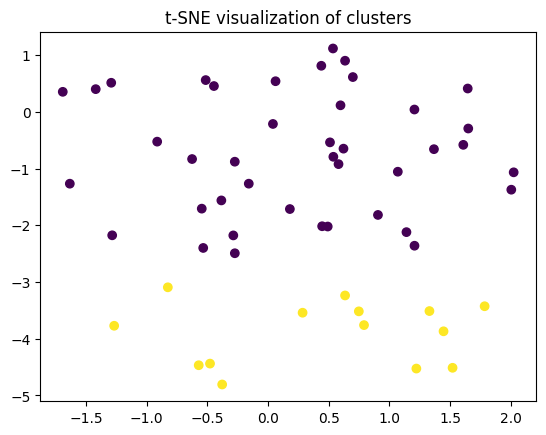

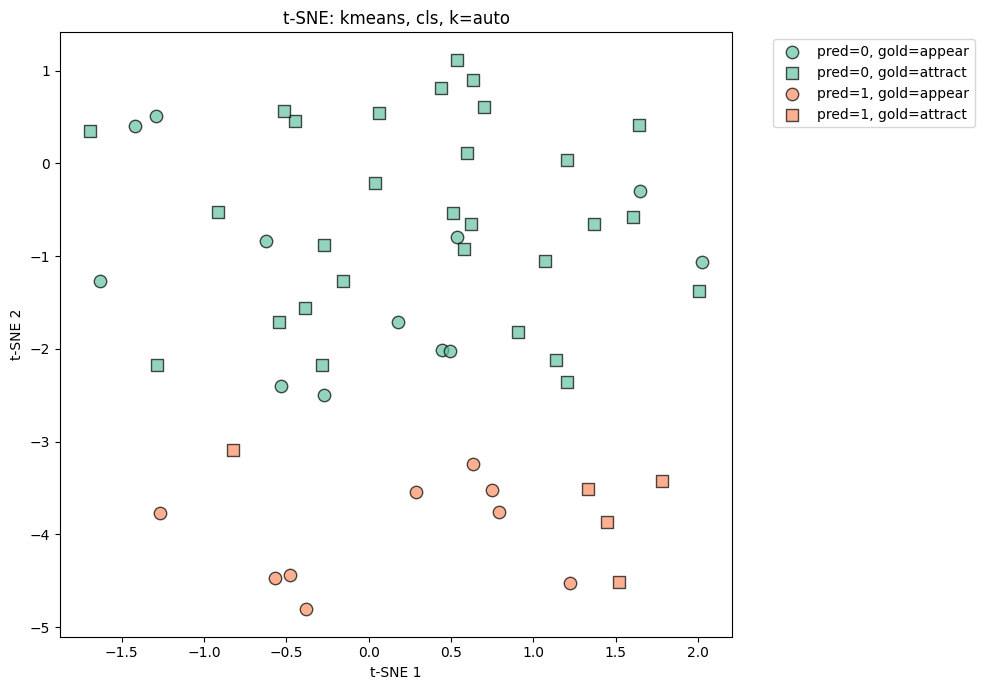


 misclassified examples

text: saturday th jan yep is going to be laying down some funky ukg dubs to [MASK] power and success in your come down to the basement for an afternoon seminar with incognito radio and friends oh yeah will be providing the food you all
gold: attract pred: 0

text: the tube map of yor mind the map is not the territory i went to an illuminating talk by advertising guru and behavioural science expert rory sutherland today one highlight amongst many was his use of the london tube map to illustrate the mental maps we all create in our minds as means for navigating and understanding the world just like the london tube map our mental maps contain distortions all based on the way we laid down and encoded them experience after experience and from a psychology perspective these distortions are [MASK] as cognitive biases and heuristics now rory was highlighting how problems can arise when we are all begin to use the same maps what i took from this was how societal influe

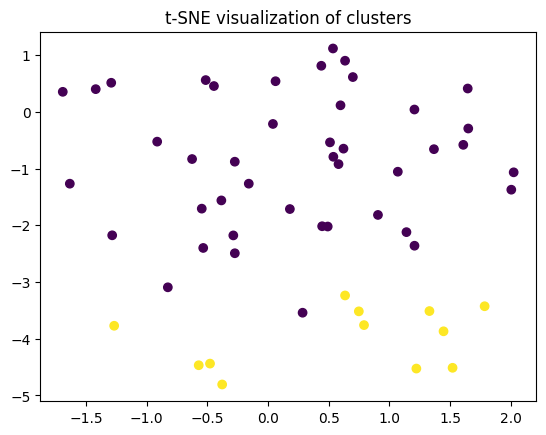

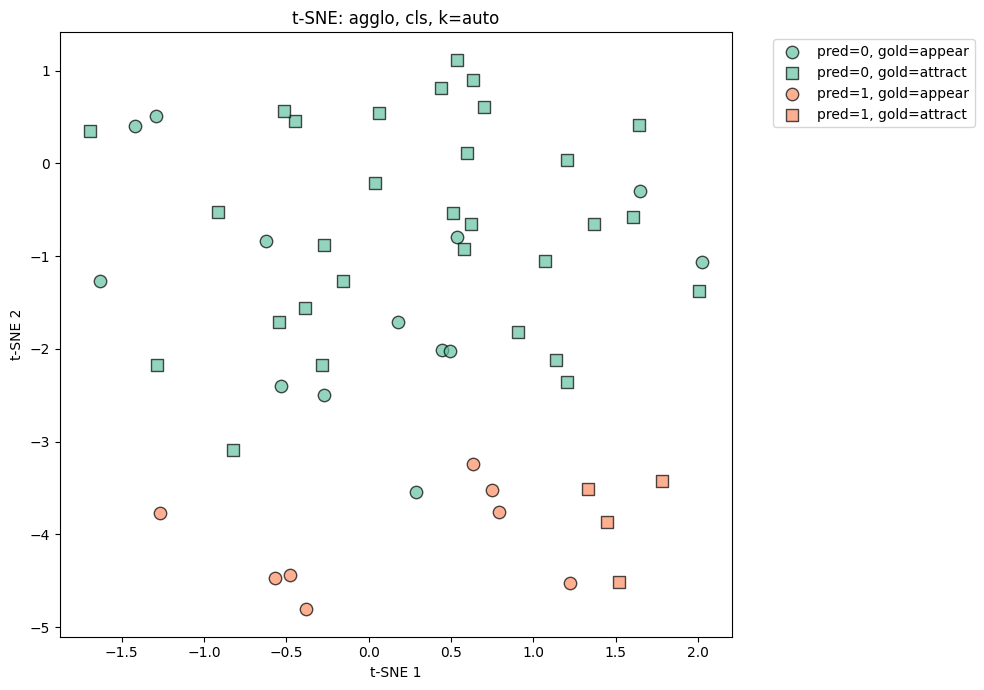


 misclassified examples

text: saturday th jan yep is going to be laying down some funky ukg dubs to [MASK] power and success in your come down to the basement for an afternoon seminar with incognito radio and friends oh yeah will be providing the food you all
gold: attract pred: 0

text: the tube map of yor mind the map is not the territory i went to an illuminating talk by advertising guru and behavioural science expert rory sutherland today one highlight amongst many was his use of the london tube map to illustrate the mental maps we all create in our minds as means for navigating and understanding the world just like the london tube map our mental maps contain distortions all based on the way we laid down and encoded them experience after experience and from a psychology perspective these distortions are [MASK] as cognitive biases and heuristics now rory was highlighting how problems can arise when we are all begin to use the same maps what i took from this was how societal influe

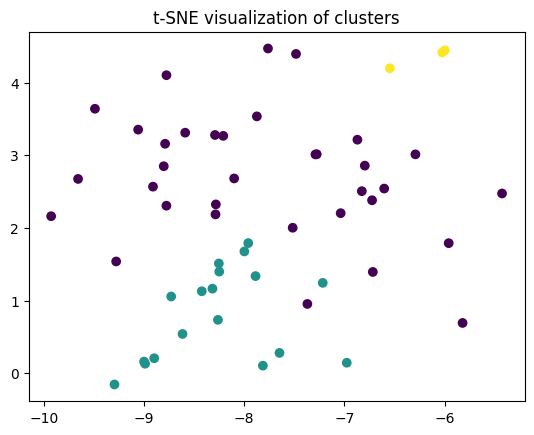

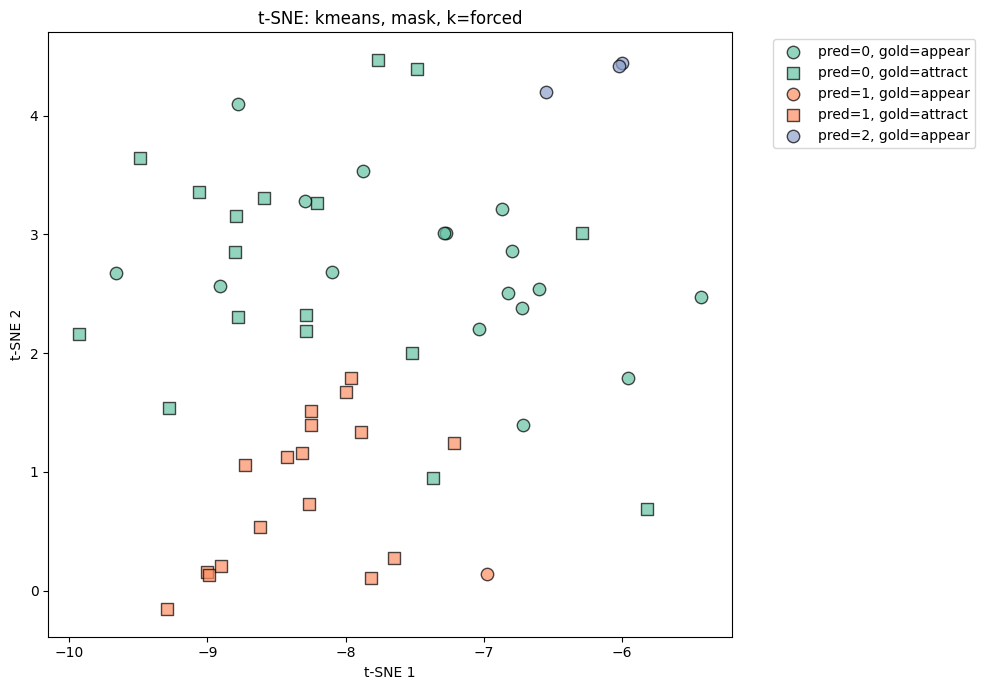


 misclassified examples

text: saturday th jan yep is going to be laying down some funky ukg dubs to [MASK] power and success in your come down to the basement for an afternoon seminar with incognito radio and friends oh yeah will be providing the food you all
gold: attract pred: 1

text: the tube map of yor mind the map is not the territory i went to an illuminating talk by advertising guru and behavioural science expert rory sutherland today one highlight amongst many was his use of the london tube map to illustrate the mental maps we all create in our minds as means for navigating and understanding the world just like the london tube map our mental maps contain distortions all based on the way we laid down and encoded them experience after experience and from a psychology perspective these distortions are [MASK] as cognitive biases and heuristics now rory was highlighting how problems can arise when we are all begin to use the same maps what i took from this was how societal influe

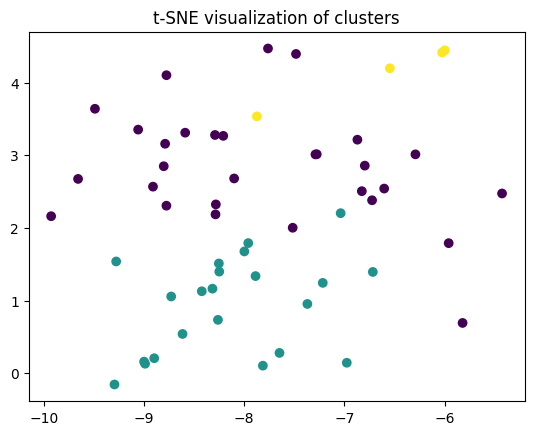

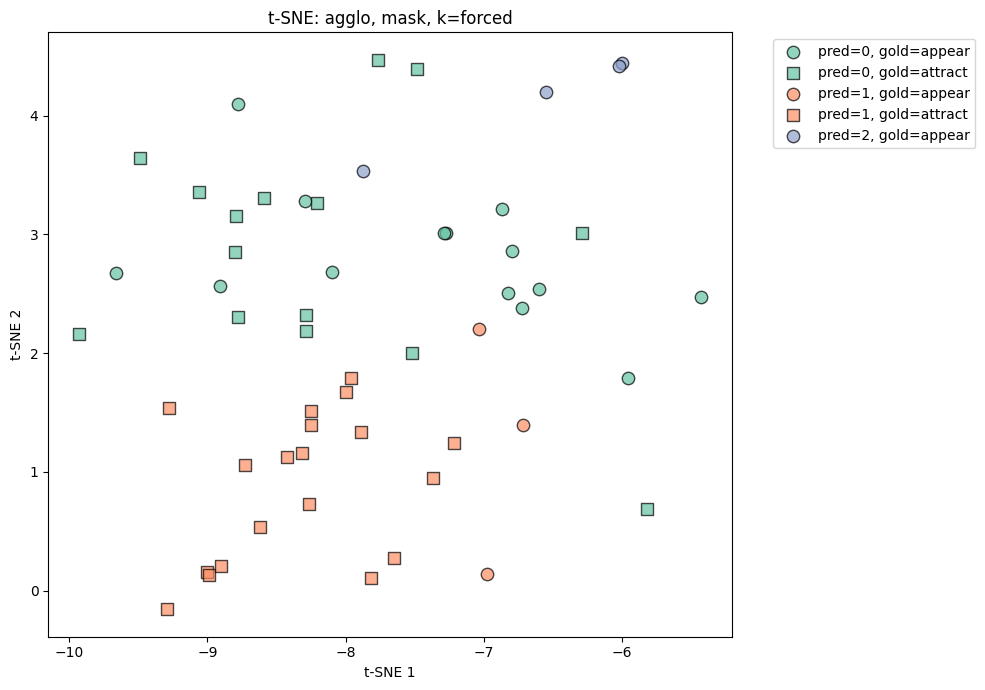


 misclassified examples

text: saturday th jan yep is going to be laying down some funky ukg dubs to [MASK] power and success in your come down to the basement for an afternoon seminar with incognito radio and friends oh yeah will be providing the food you all
gold: attract pred: 1

text: the tube map of yor mind the map is not the territory i went to an illuminating talk by advertising guru and behavioural science expert rory sutherland today one highlight amongst many was his use of the london tube map to illustrate the mental maps we all create in our minds as means for navigating and understanding the world just like the london tube map our mental maps contain distortions all based on the way we laid down and encoded them experience after experience and from a psychology perspective these distortions are [MASK] as cognitive biases and heuristics now rory was highlighting how problems can arise when we are all begin to use the same maps what i took from this was how societal influe

In [ ]:
terms = ["manifest"]

all_results = []
for term in terms:
    print("term:", term)

    df = pd.read_csv(f"data/{term}_annotation.csv")

    configs = [
    # RANDOM BASELINE
    ("random", "mask", "fixed", 3),

    # SIMPLE BASELINE (1 cluster)
    ("baseline", "mask", "fixed", 1),

    # TF-IDF baseline (НОВЫЙ)
    ("kmeans", "tfidf", "auto", None),

    # MAIN MODELS
    ("kmeans", "mask", "auto", None),
    ("agglo", "mask", "auto", None),

    ("kmeans", "cls", "auto", None),
    ("agglo", "cls", "auto", None),

    # FIXED K
    ("kmeans", "mask", "forced", 3),
    ("agglo", "mask", "forced", 3),
]

    for method, emb, k_mode, k in configs:

        print(f"\n {method} | {emb} | {k_mode}")

        res = run_pipeline(
            df,
            tokenizer,
            encoder_model,
            device,
            method=method,
            embedding_type=emb,
            k_mode=k_mode,
            forced_k=k
        )
        plot_confusion_matrix(res, title=f"{term} - {method} {emb} {k_mode}")
        plot_tsne(res["X"], res["labels"])

        plot_tsne_with_shapes(
            X=res["X"],
            pred_labels=res["labels"],
            gold_labels=res["gold"],
            title=f"t-SNE: {method}, {emb}, k={k_mode}"
        )

        show_mismatches(
            res["texts"],
            res["gold"],
            res["labels"]
        )

        print(res["metrics"])

        row = res["metrics"].copy()
        row["method"] = method
        row["embedding"] = emb
        all_results.append(row)


        if method in ["kmeans", "agglo", "hybrid"]:
            show_clusters(
                res["texts"],
                res["labels"],
                res["gold"]
            )


    print("\n CLUSTER-LEVEL SYNONYMS")

    clusters = {}
    for text, label in zip(res["original_texts"], res["labels"]):
        clusters.setdefault(label, []).append(text)

    for cluster_id, texts_cluster in clusters.items():
        freq_syns = cluster_synonyms_freq(texts_cluster, term, tokenizer, mlm_model, device)
        logit_syns = cluster_synonyms_logits(texts_cluster, term, tokenizer, mlm_model, device)

        print("Logits:", logit_syns)


df_results = pd.DataFrame(all_results)
df_results.to_csv("results/results.csv", index=False)

print("\n final results:")
print(df_results)

term: ish

 random | mask | fixed


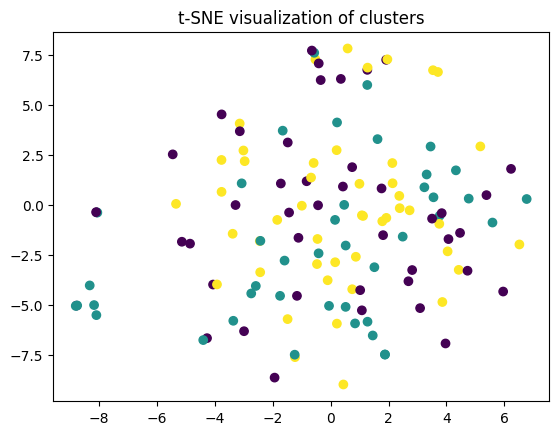

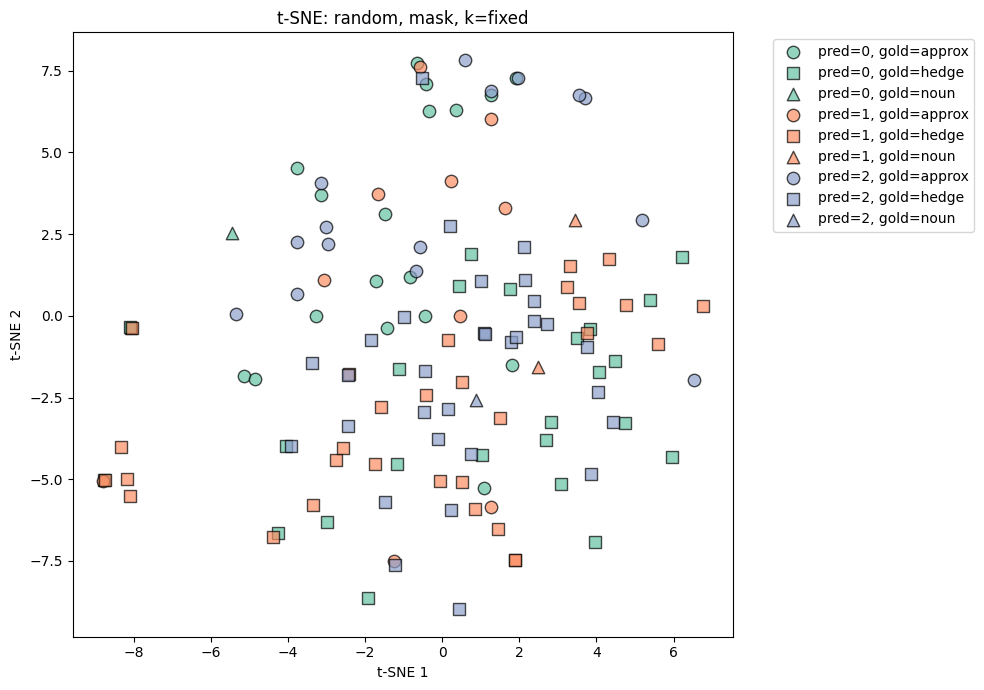


 misclassified examples

text: the maestro is back in the or as i like to call it do not know the name of this one but it is of and sliced thinly freshly and s sliced with more seasoning for [MASK] minutes to soften then add the fish with more seasoning style food we cannot get enough of this one never tried it with jerusalem artichokes before so i will be interested to see how it turns out i will be posting the end results shortly it is good to be getting back into my normal routine it is all been a blur with the ton of meds and but i am enjoying life with my little family who have all been there for me thanks for all the kind messages i really am a lucky guy
gold: hedge pred: 2

text: happy new year babes i have been talking a lot on about strength and getting stronger this year above are three exercises great for increasing your strength this year deadlifts with a pulse deadlifts into a front squat side squat walks deadlifts squats are my two favourite exercises by adding tension p

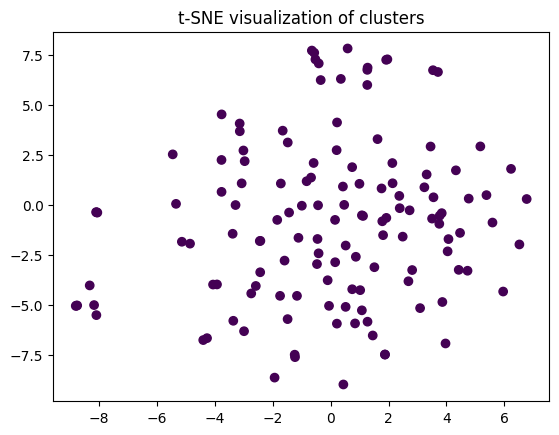

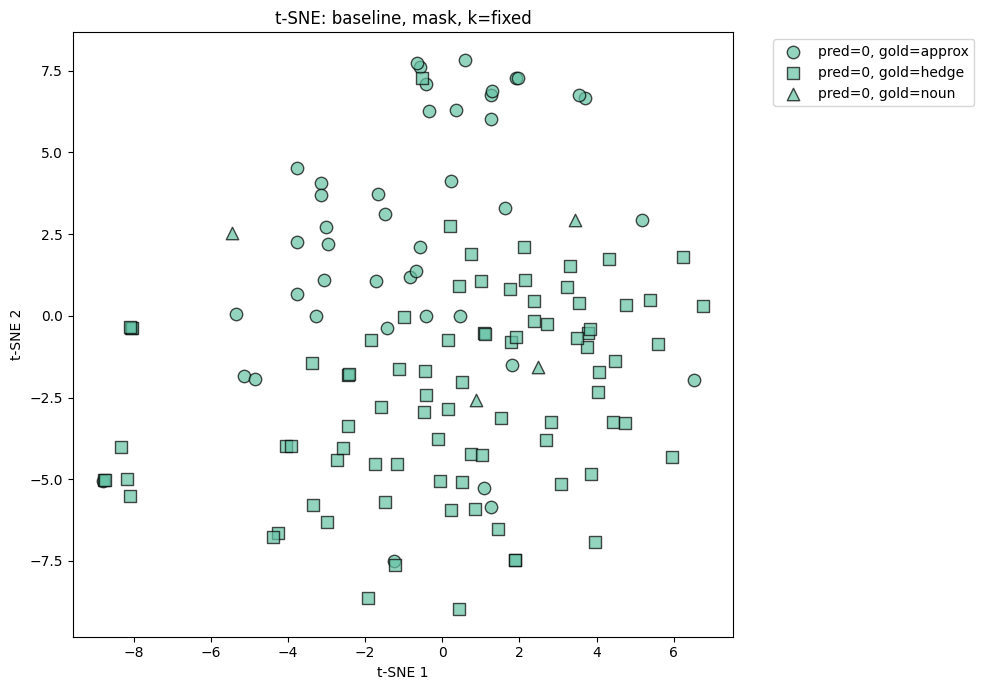


 misclassified examples

text: the maestro is back in the or as i like to call it do not know the name of this one but it is of and sliced thinly freshly and s sliced with more seasoning for [MASK] minutes to soften then add the fish with more seasoning style food we cannot get enough of this one never tried it with jerusalem artichokes before so i will be interested to see how it turns out i will be posting the end results shortly it is good to be getting back into my normal routine it is all been a blur with the ton of meds and but i am enjoying life with my little family who have all been there for me thanks for all the kind messages i really am a lucky guy
gold: hedge pred: 0

text: happy new year babes i have been talking a lot on about strength and getting stronger this year above are three exercises great for increasing your strength this year deadlifts with a pulse deadlifts into a front squat side squat walks deadlifts squats are my two favourite exercises by adding tension p

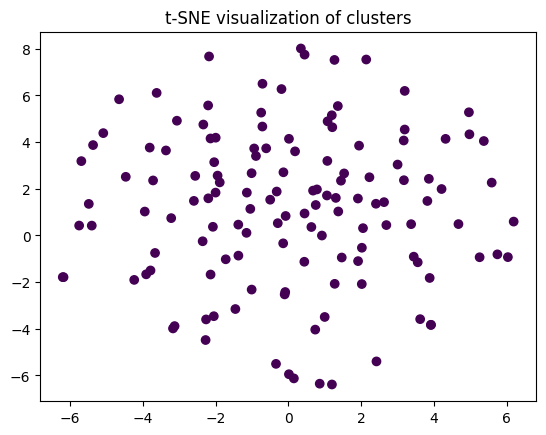

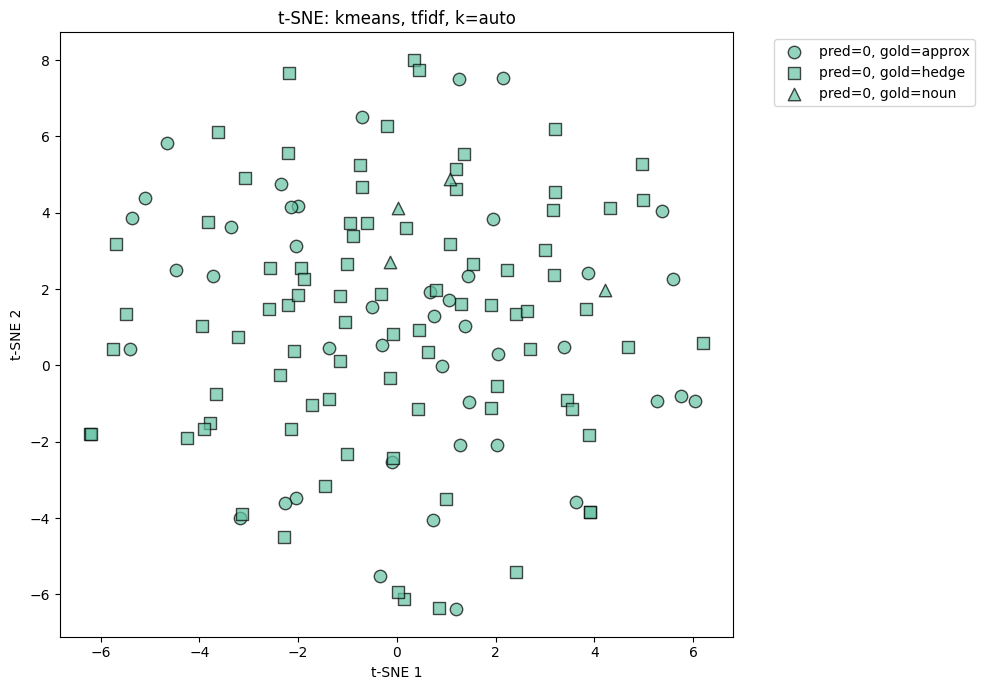


 misclassified examples

text: the maestro is back in the or as i like to call it do not know the name of this one but it is of and sliced thinly freshly and s sliced with more seasoning for [MASK] minutes to soften then add the fish with more seasoning style food we cannot get enough of this one never tried it with jerusalem artichokes before so i will be interested to see how it turns out i will be posting the end results shortly it is good to be getting back into my normal routine it is all been a blur with the ton of meds and but i am enjoying life with my little family who have all been there for me thanks for all the kind messages i really am a lucky guy
gold: hedge pred: 0

text: happy new year babes i have been talking a lot on about strength and getting stronger this year above are three exercises great for increasing your strength this year deadlifts with a pulse deadlifts into a front squat side squat walks deadlifts squats are my two favourite exercises by adding tension p

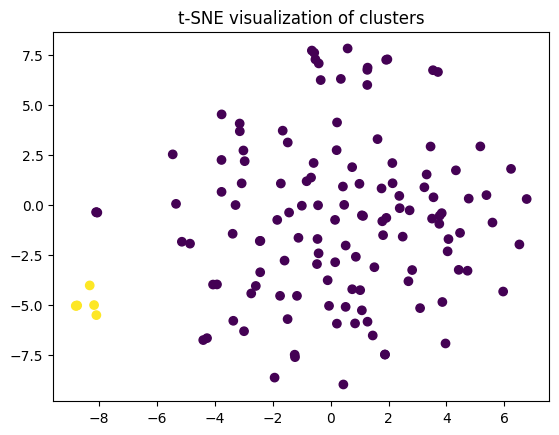

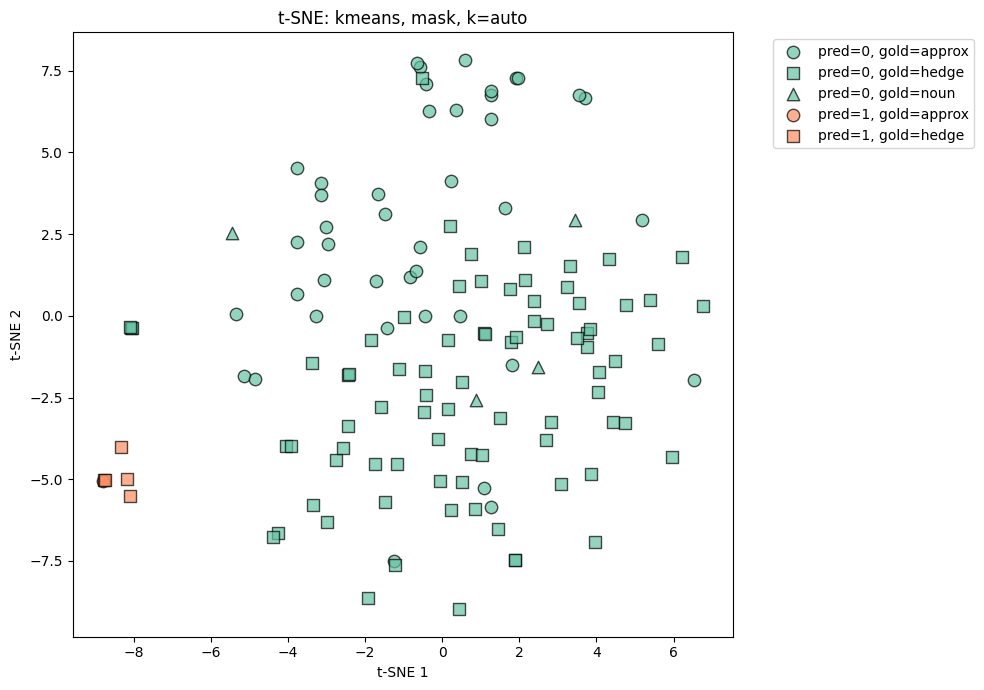


 misclassified examples

text: the maestro is back in the or as i like to call it do not know the name of this one but it is of and sliced thinly freshly and s sliced with more seasoning for [MASK] minutes to soften then add the fish with more seasoning style food we cannot get enough of this one never tried it with jerusalem artichokes before so i will be interested to see how it turns out i will be posting the end results shortly it is good to be getting back into my normal routine it is all been a blur with the ton of meds and but i am enjoying life with my little family who have all been there for me thanks for all the kind messages i really am a lucky guy
gold: hedge pred: 0

text: happy new year babes i have been talking a lot on about strength and getting stronger this year above are three exercises great for increasing your strength this year deadlifts with a pulse deadlifts into a front squat side squat walks deadlifts squats are my two favourite exercises by adding tension p

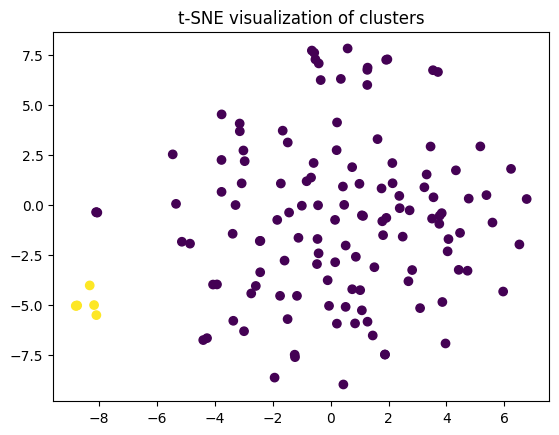

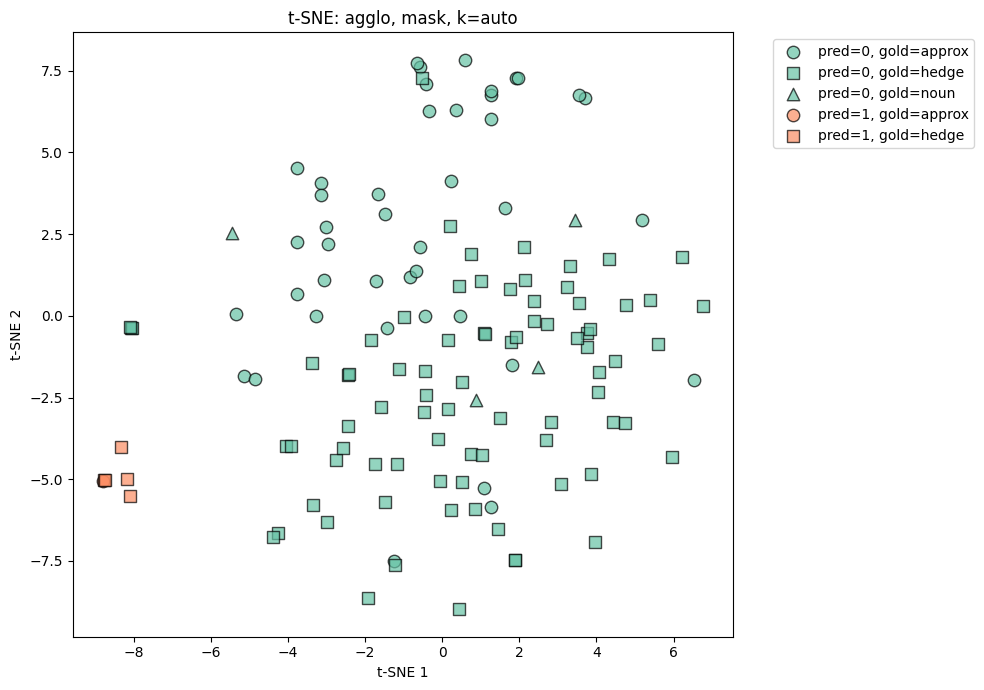


 misclassified examples

text: the maestro is back in the or as i like to call it do not know the name of this one but it is of and sliced thinly freshly and s sliced with more seasoning for [MASK] minutes to soften then add the fish with more seasoning style food we cannot get enough of this one never tried it with jerusalem artichokes before so i will be interested to see how it turns out i will be posting the end results shortly it is good to be getting back into my normal routine it is all been a blur with the ton of meds and but i am enjoying life with my little family who have all been there for me thanks for all the kind messages i really am a lucky guy
gold: hedge pred: 0

text: happy new year babes i have been talking a lot on about strength and getting stronger this year above are three exercises great for increasing your strength this year deadlifts with a pulse deadlifts into a front squat side squat walks deadlifts squats are my two favourite exercises by adding tension p

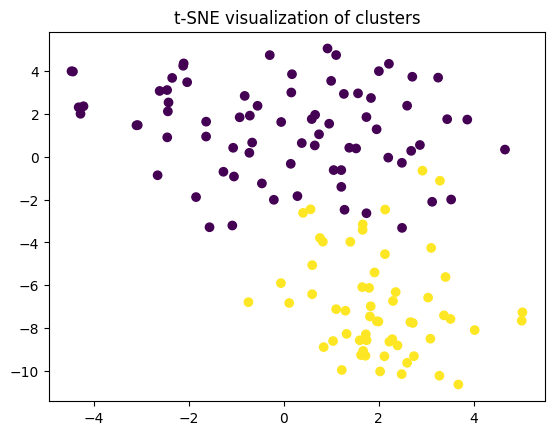

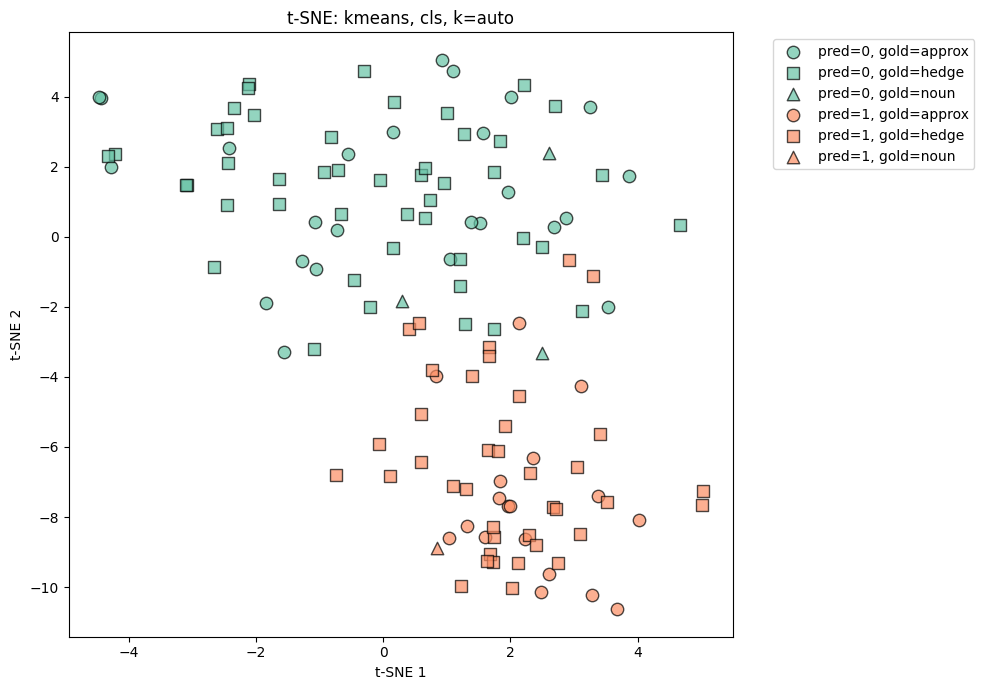


 misclassified examples

text: the maestro is back in the or as i like to call it do not know the name of this one but it is of and sliced thinly freshly and s sliced with more seasoning for [MASK] minutes to soften then add the fish with more seasoning style food we cannot get enough of this one never tried it with jerusalem artichokes before so i will be interested to see how it turns out i will be posting the end results shortly it is good to be getting back into my normal routine it is all been a blur with the ton of meds and but i am enjoying life with my little family who have all been there for me thanks for all the kind messages i really am a lucky guy
gold: hedge pred: 0

text: happy new year babes i have been talking a lot on about strength and getting stronger this year above are three exercises great for increasing your strength this year deadlifts with a pulse deadlifts into a front squat side squat walks deadlifts squats are my two favourite exercises by adding tension p

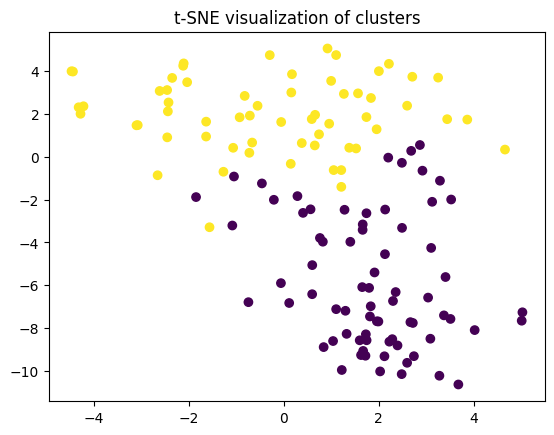

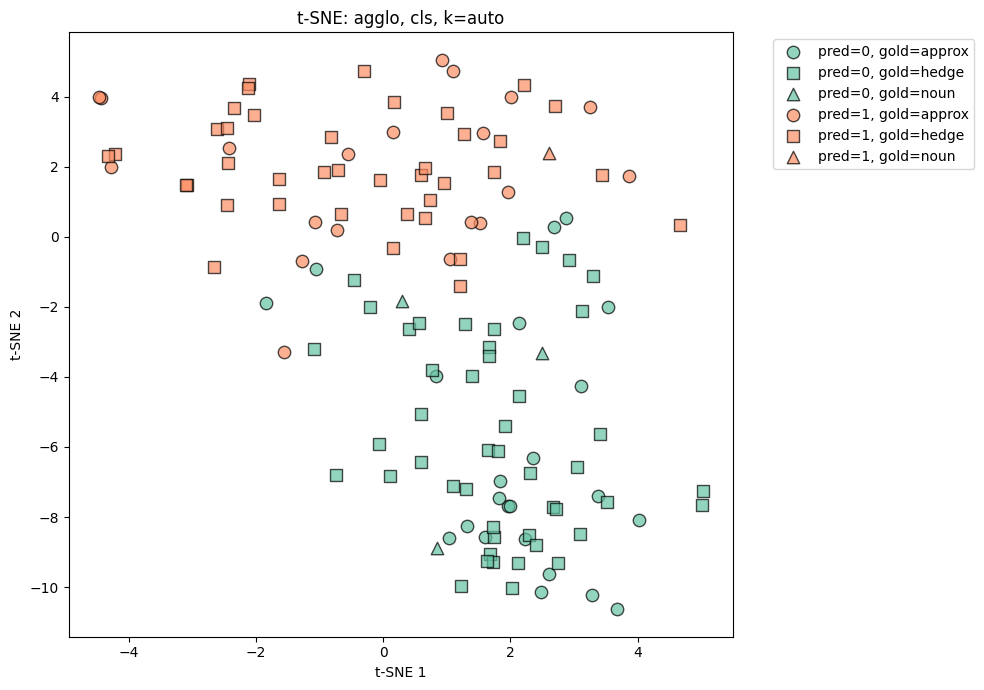


 misclassified examples

text: the maestro is back in the or as i like to call it do not know the name of this one but it is of and sliced thinly freshly and s sliced with more seasoning for [MASK] minutes to soften then add the fish with more seasoning style food we cannot get enough of this one never tried it with jerusalem artichokes before so i will be interested to see how it turns out i will be posting the end results shortly it is good to be getting back into my normal routine it is all been a blur with the ton of meds and but i am enjoying life with my little family who have all been there for me thanks for all the kind messages i really am a lucky guy
gold: hedge pred: 1

text: happy new year babes i have been talking a lot on about strength and getting stronger this year above are three exercises great for increasing your strength this year deadlifts with a pulse deadlifts into a front squat side squat walks deadlifts squats are my two favourite exercises by adding tension p

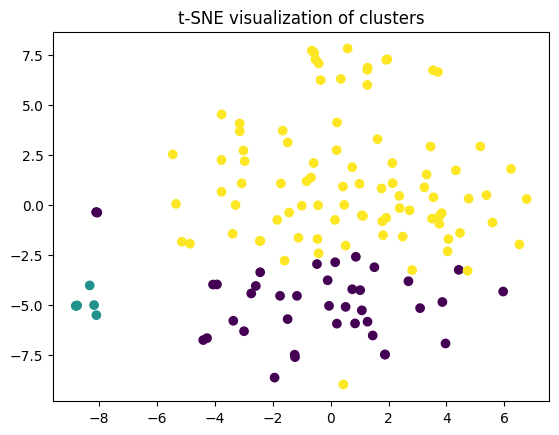

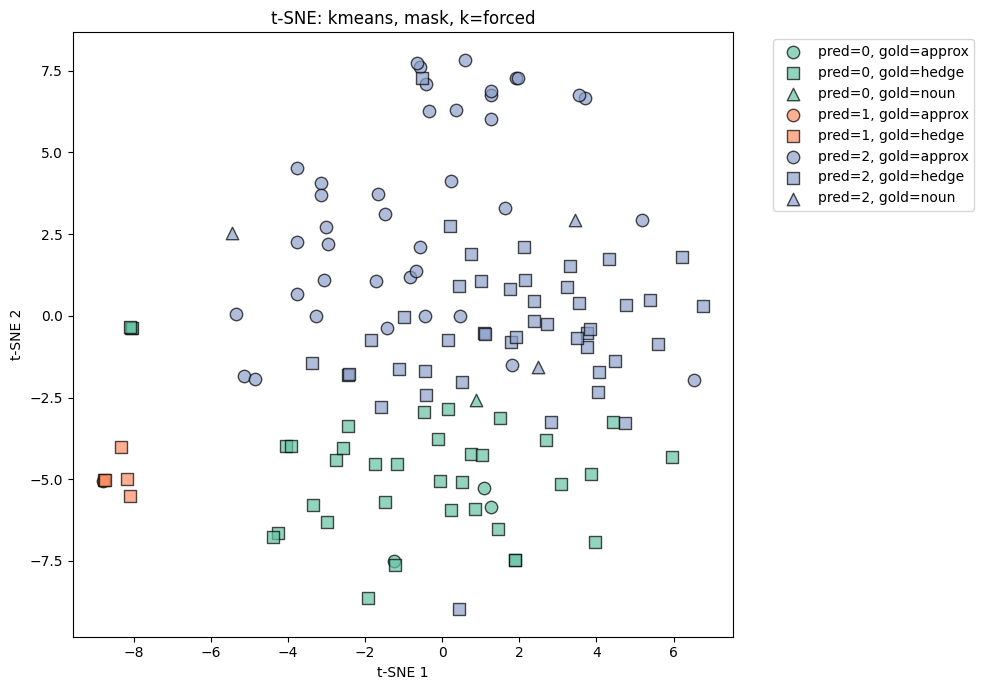


 misclassified examples

text: the maestro is back in the or as i like to call it do not know the name of this one but it is of and sliced thinly freshly and s sliced with more seasoning for [MASK] minutes to soften then add the fish with more seasoning style food we cannot get enough of this one never tried it with jerusalem artichokes before so i will be interested to see how it turns out i will be posting the end results shortly it is good to be getting back into my normal routine it is all been a blur with the ton of meds and but i am enjoying life with my little family who have all been there for me thanks for all the kind messages i really am a lucky guy
gold: hedge pred: 2

text: happy new year babes i have been talking a lot on about strength and getting stronger this year above are three exercises great for increasing your strength this year deadlifts with a pulse deadlifts into a front squat side squat walks deadlifts squats are my two favourite exercises by adding tension p

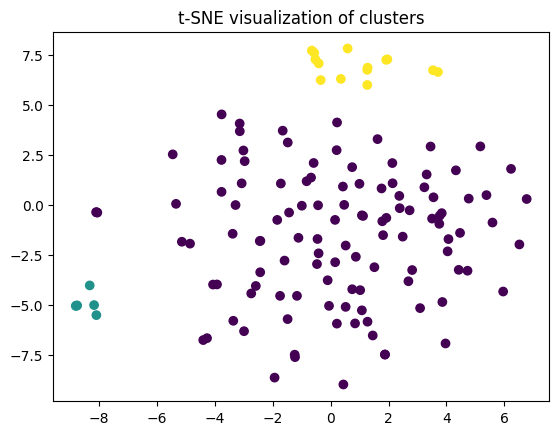

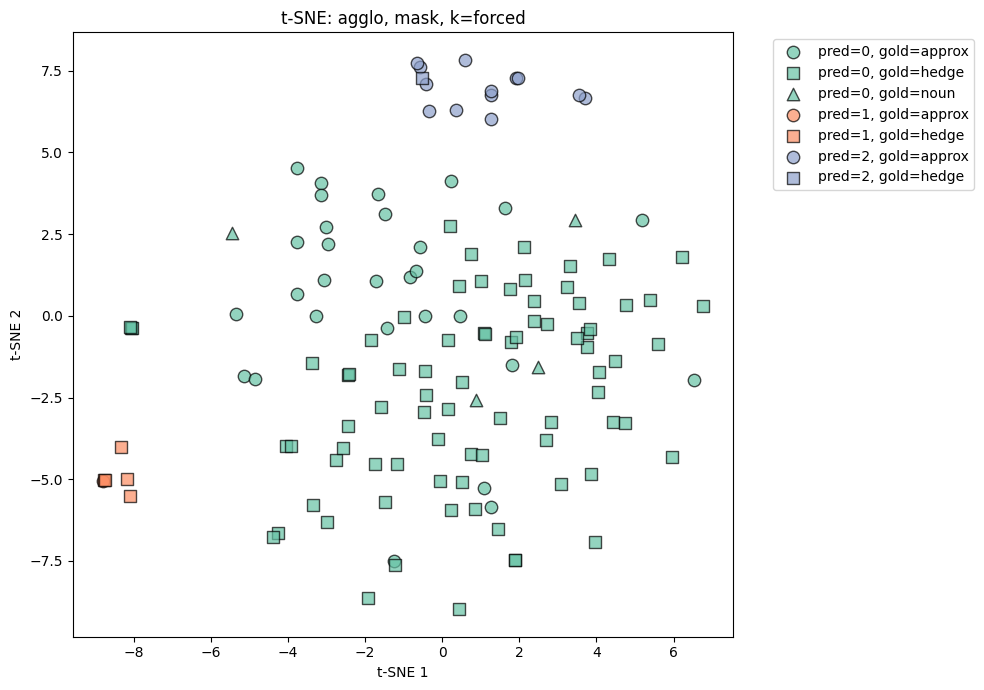


 misclassified examples

text: the maestro is back in the or as i like to call it do not know the name of this one but it is of and sliced thinly freshly and s sliced with more seasoning for [MASK] minutes to soften then add the fish with more seasoning style food we cannot get enough of this one never tried it with jerusalem artichokes before so i will be interested to see how it turns out i will be posting the end results shortly it is good to be getting back into my normal routine it is all been a blur with the ton of meds and but i am enjoying life with my little family who have all been there for me thanks for all the kind messages i really am a lucky guy
gold: hedge pred: 2

text: happy new year babes i have been talking a lot on about strength and getting stronger this year above are three exercises great for increasing your strength this year deadlifts with a pulse deadlifts into a front squat side squat walks deadlifts squats are my two favourite exercises by adding tension p

In [ ]:
terms = ["ish"]

all_results = []

for term in terms:
    print("term:", term)

    df = pd.read_csv(f"data/{term}_annotation.csv")

    configs = [
    # RANDOM BASELINE
    ("random", "mask", "fixed", 3),

    # SIMPLE BASELINE (1 cluster)
    ("baseline", "mask", "fixed", 1),

    # TF-IDF baseline (НОВЫЙ)
    ("kmeans", "tfidf", "auto", None),

    # MAIN MODELS
    ("kmeans", "mask", "auto", None),
    ("agglo", "mask", "auto", None),

    ("kmeans", "cls", "auto", None),
    ("agglo", "cls", "auto", None),

    # FIXED K
    ("kmeans", "mask", "forced", 3),
    ("agglo", "mask", "forced", 3),
]

    for method, emb, k_mode, k in configs:

        print(f"\n {method} | {emb} | {k_mode}")

        res = run_pipeline(
            df,
            tokenizer,
            encoder_model,
            device,
            method=method,
            embedding_type=emb,
            k_mode=k_mode,
            forced_k=k
        )
        plot_confusion_matrix(res, title=f"{term} - {method} {emb} {k_mode}")
        plot_tsne(res["X"], res["labels"])

        plot_tsne_with_shapes(
            X=res["X"],
            pred_labels=res["labels"],
            gold_labels=res["gold"],
            title=f"t-SNE: {method}, {emb}, k={k_mode}"
        )

        show_mismatches(
            res["texts"],
            res["gold"],
            res["labels"]
        )

        print(res["metrics"])

        row = res["metrics"].copy()
        row["method"] = method
        row["embedding"] = emb
        all_results.append(row)


        if method in ["kmeans", "agglo", "hybrid"]:
            show_clusters(
                res["texts"],
                res["labels"],
                res["gold"]
            )


    print("\n CLUSTER-LEVEL SYNONYMS")

    clusters = {}
    for text, label in zip(res["original_texts"], res["labels"]):
        clusters.setdefault(label, []).append(text)

    for cluster_id, texts_cluster in clusters.items():
        freq_syns = cluster_synonyms_freq(texts_cluster, term, tokenizer, mlm_model, device)
        logit_syns = cluster_synonyms_logits(texts_cluster, term, tokenizer, mlm_model, device)

        print("Logits:", logit_syns)


df_results = pd.DataFrame(all_results)
df_results.to_csv("results/results.csv", index=False)

print("\n final results:")
print(df_results)

term: uber

 random | mask | fixed


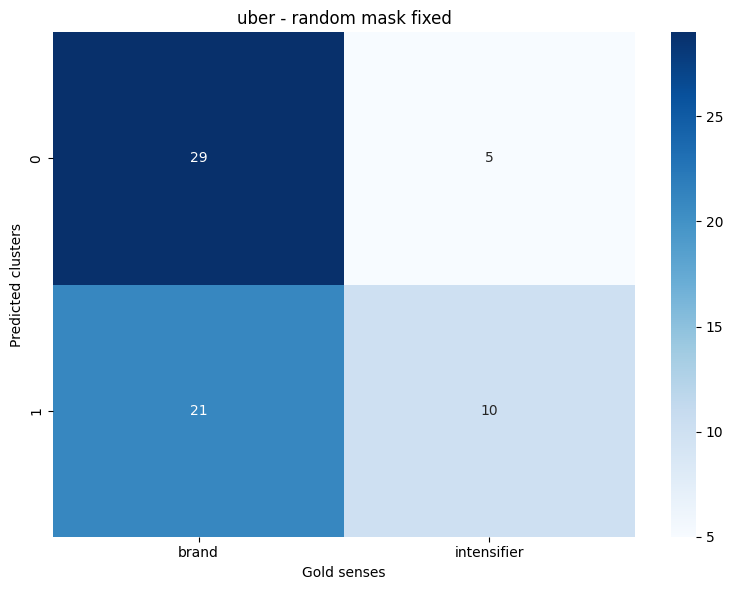

Dominant gold sense per cluster: {0: 'brand', 1: 'brand'}


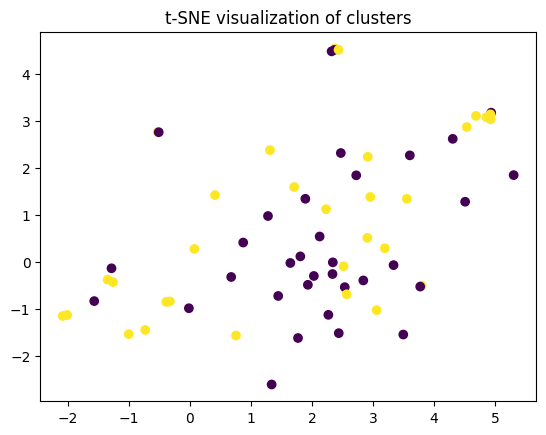

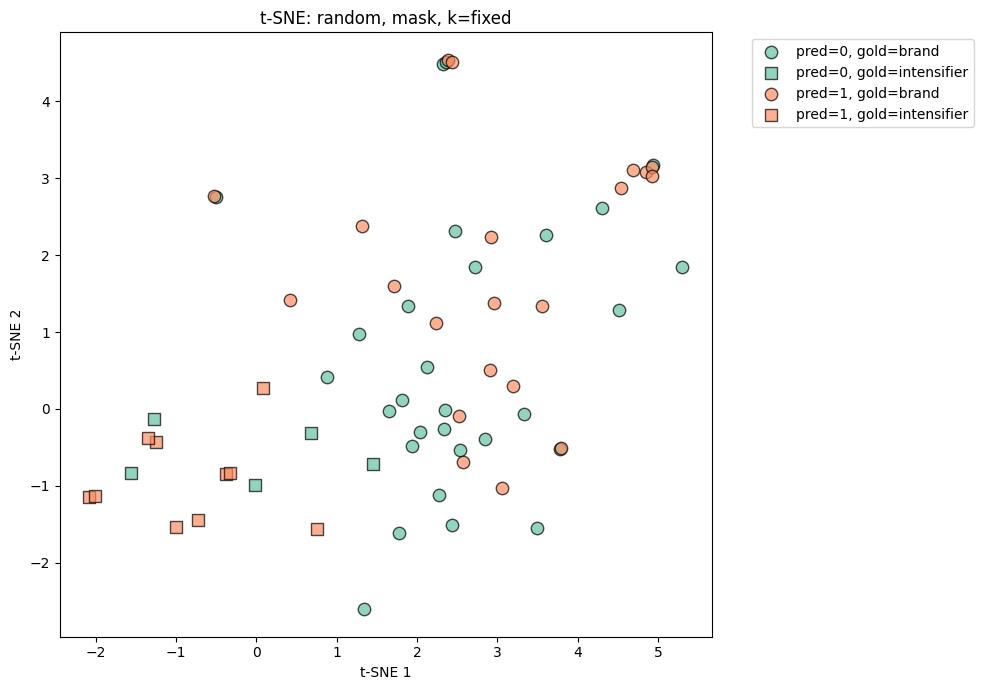


 misclassified examples

text: i have never posted on the theme of before but i must confess is probably the closest it is going to get on insta always dressed totally fabulous and so much fun to work with on our christmas party she is also [MASK] talented at making vibrant jewellery and sells awesome vintage clothes such as the jumpsuit i am wearing in this photo give us a like and follow her page if you want to look this ace too
gold: intensifier pred: 0

text: now pouring on our draught all for one hazy ipa abv a big juicy hazy american ipa brewed in collaboration with megan stone this juicy [MASK] hoppy beer is double dry hopped with citra motueka cascade giving it powerful american muscle flavours of passionfruit grapefruit citrus tropical fruits brewed as part of all for one one for all diversity campaign enjoy it
gold: intensifier pred: 1

text: highly recommend pregaming with [MASK] eats
gold: brand pred: 0

text: truly an icon but about to disappear the one and only london bl

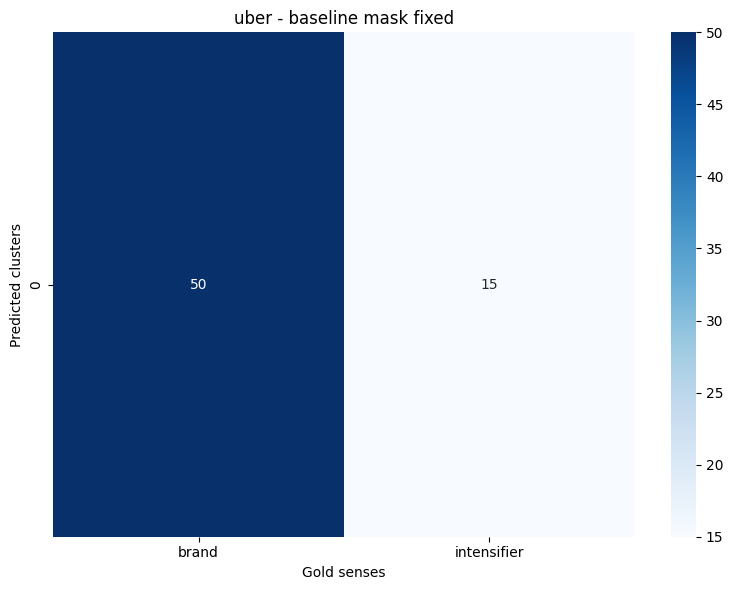

Dominant gold sense per cluster: {0: 'brand'}


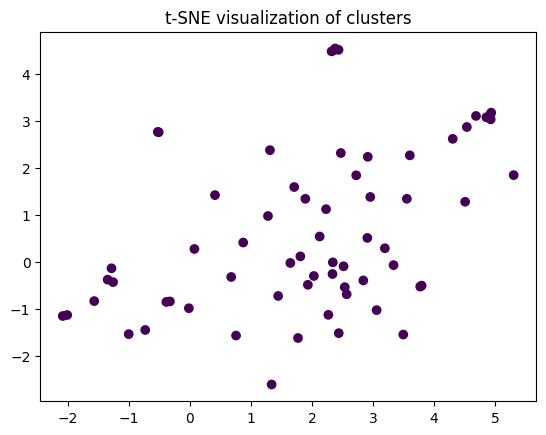

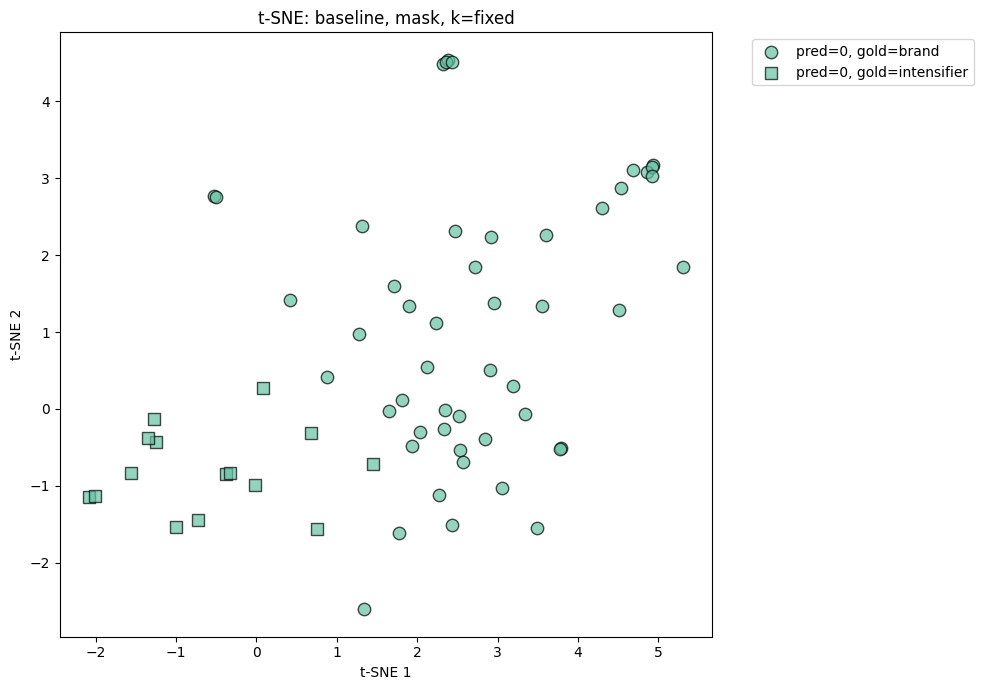


 misclassified examples

text: i have never posted on the theme of before but i must confess is probably the closest it is going to get on insta always dressed totally fabulous and so much fun to work with on our christmas party she is also [MASK] talented at making vibrant jewellery and sells awesome vintage clothes such as the jumpsuit i am wearing in this photo give us a like and follow her page if you want to look this ace too
gold: intensifier pred: 0

text: now pouring on our draught all for one hazy ipa abv a big juicy hazy american ipa brewed in collaboration with megan stone this juicy [MASK] hoppy beer is double dry hopped with citra motueka cascade giving it powerful american muscle flavours of passionfruit grapefruit citrus tropical fruits brewed as part of all for one one for all diversity campaign enjoy it
gold: intensifier pred: 0

text: highly recommend pregaming with [MASK] eats
gold: brand pred: 0

text: truly an icon but about to disappear the one and only london bl

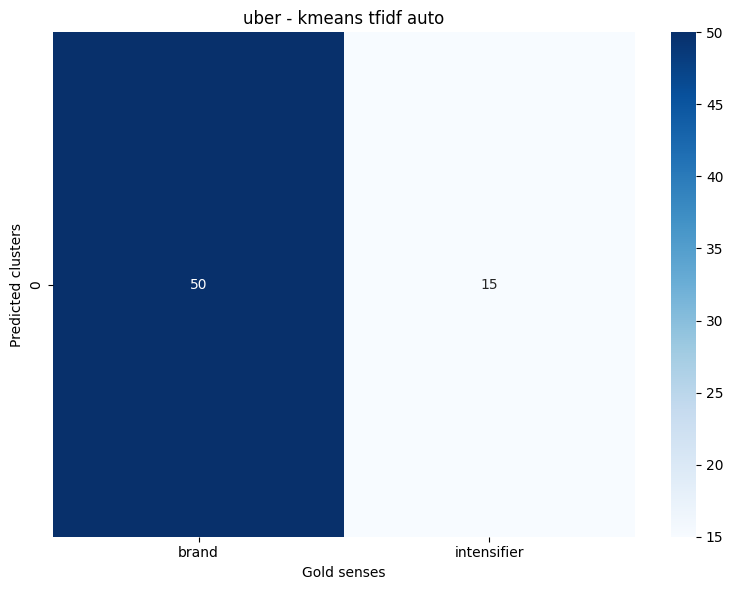

Dominant gold sense per cluster: {0: 'brand'}


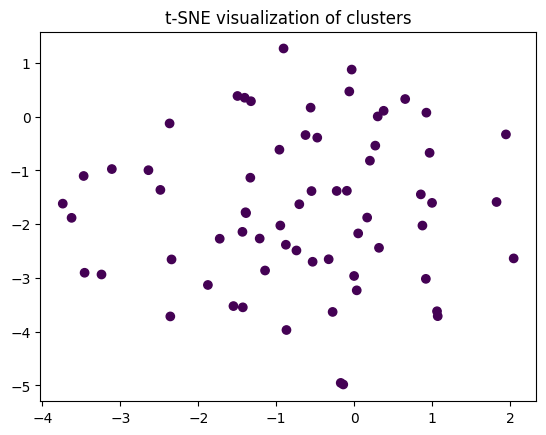

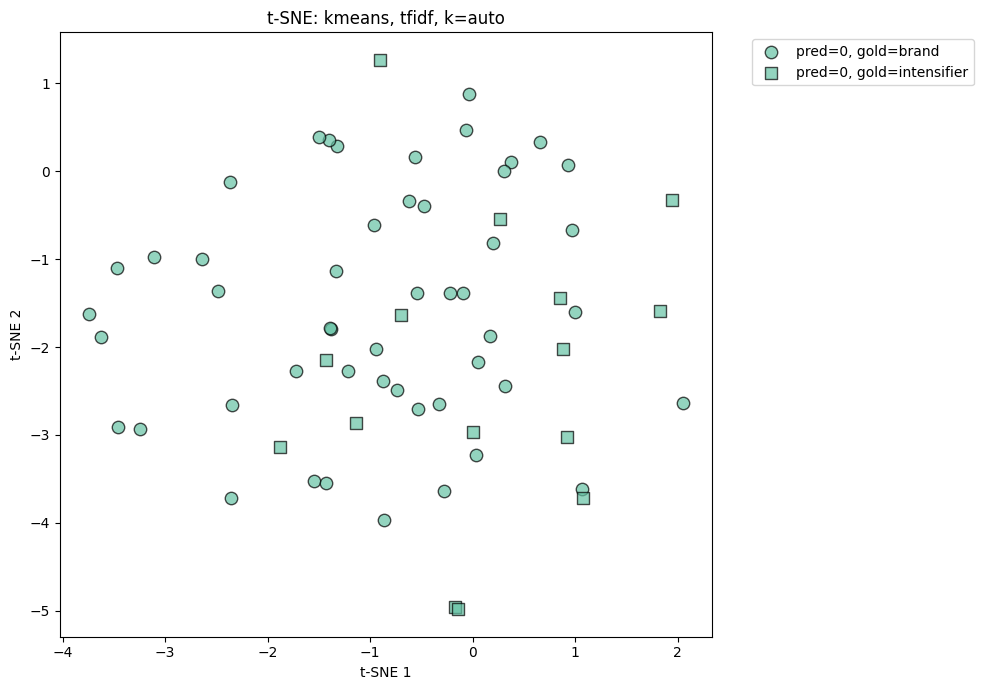


 misclassified examples

text: i have never posted on the theme of before but i must confess is probably the closest it is going to get on insta always dressed totally fabulous and so much fun to work with on our christmas party she is also [MASK] talented at making vibrant jewellery and sells awesome vintage clothes such as the jumpsuit i am wearing in this photo give us a like and follow her page if you want to look this ace too
gold: intensifier pred: 0

text: now pouring on our draught all for one hazy ipa abv a big juicy hazy american ipa brewed in collaboration with megan stone this juicy [MASK] hoppy beer is double dry hopped with citra motueka cascade giving it powerful american muscle flavours of passionfruit grapefruit citrus tropical fruits brewed as part of all for one one for all diversity campaign enjoy it
gold: intensifier pred: 0

text: highly recommend pregaming with [MASK] eats
gold: brand pred: 0

text: truly an icon but about to disappear the one and only london bl

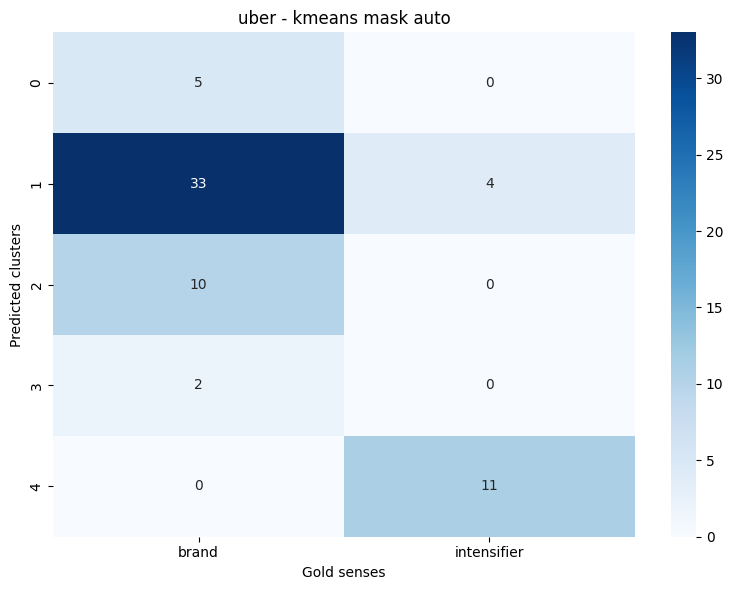

Dominant gold sense per cluster: {0: 'brand', 1: 'brand', 2: 'brand', 3: 'brand', 4: 'intensifier'}


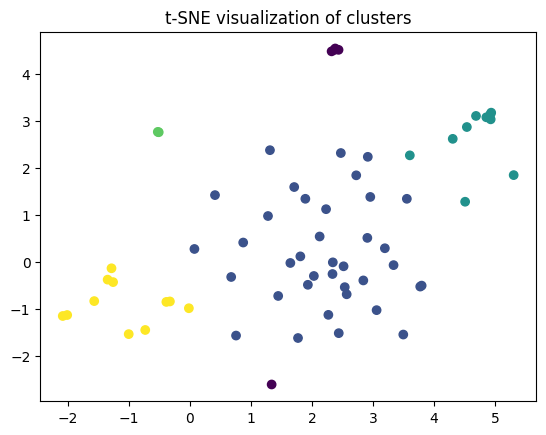

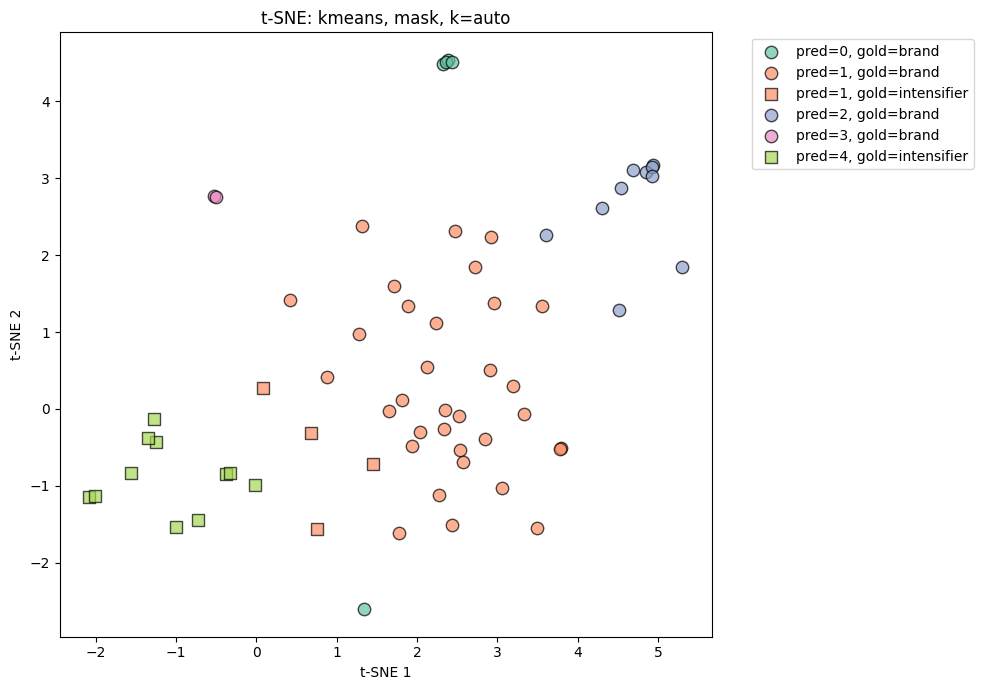


 misclassified examples

text: i have never posted on the theme of before but i must confess is probably the closest it is going to get on insta always dressed totally fabulous and so much fun to work with on our christmas party she is also [MASK] talented at making vibrant jewellery and sells awesome vintage clothes such as the jumpsuit i am wearing in this photo give us a like and follow her page if you want to look this ace too
gold: intensifier pred: 4

text: now pouring on our draught all for one hazy ipa abv a big juicy hazy american ipa brewed in collaboration with megan stone this juicy [MASK] hoppy beer is double dry hopped with citra motueka cascade giving it powerful american muscle flavours of passionfruit grapefruit citrus tropical fruits brewed as part of all for one one for all diversity campaign enjoy it
gold: intensifier pred: 1

text: highly recommend pregaming with [MASK] eats
gold: brand pred: 1

text: truly an icon but about to disappear the one and only london bl

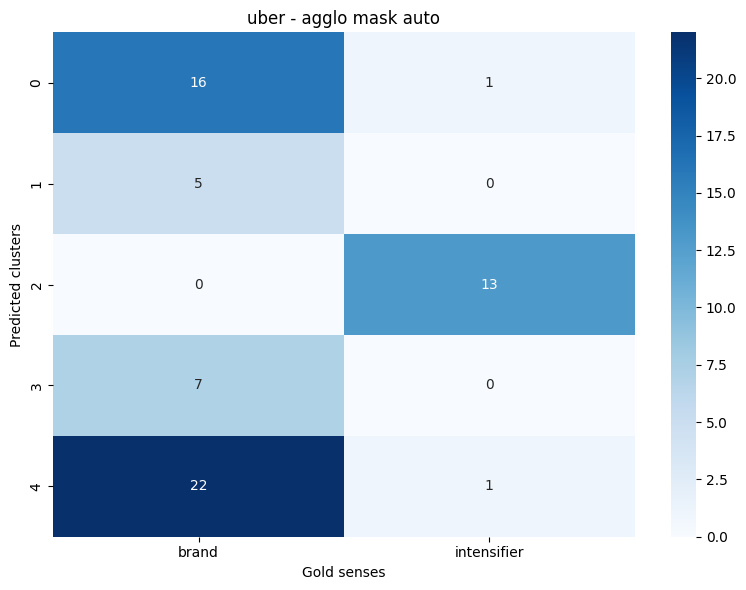

Dominant gold sense per cluster: {0: 'brand', 1: 'brand', 2: 'intensifier', 3: 'brand', 4: 'brand'}


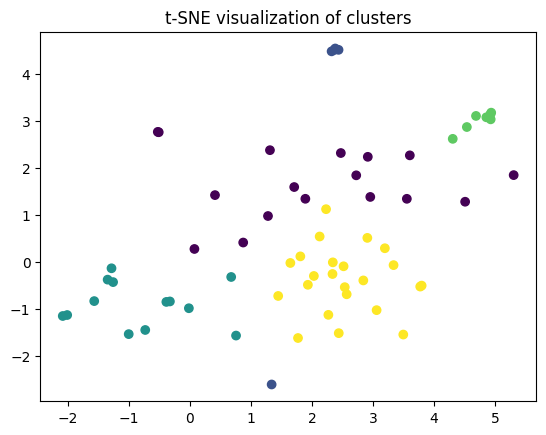

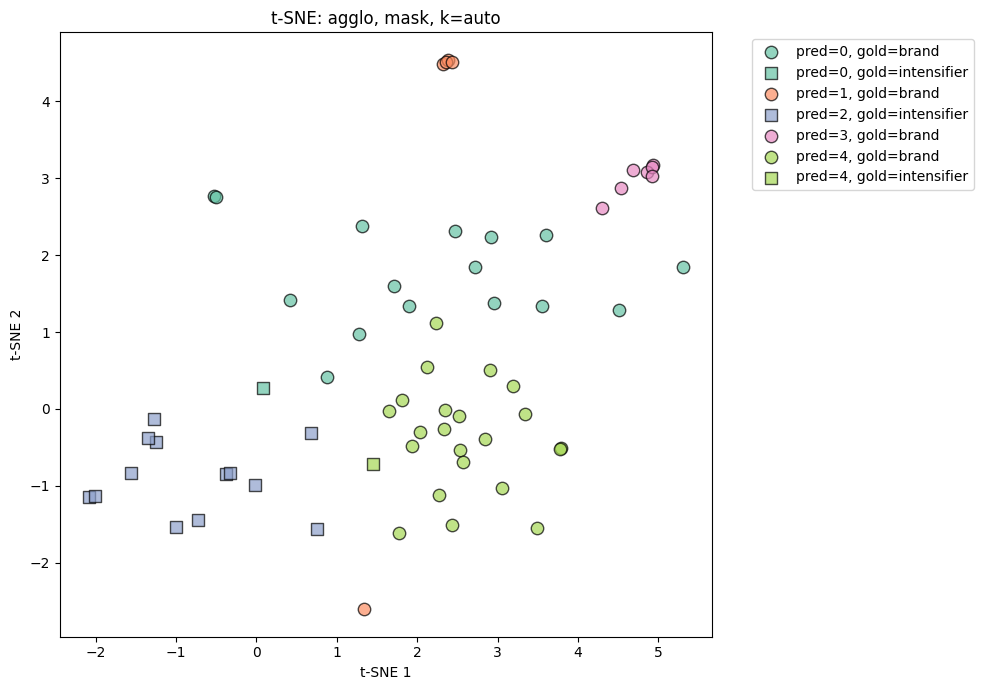


 misclassified examples

text: i have never posted on the theme of before but i must confess is probably the closest it is going to get on insta always dressed totally fabulous and so much fun to work with on our christmas party she is also [MASK] talented at making vibrant jewellery and sells awesome vintage clothes such as the jumpsuit i am wearing in this photo give us a like and follow her page if you want to look this ace too
gold: intensifier pred: 2

text: now pouring on our draught all for one hazy ipa abv a big juicy hazy american ipa brewed in collaboration with megan stone this juicy [MASK] hoppy beer is double dry hopped with citra motueka cascade giving it powerful american muscle flavours of passionfruit grapefruit citrus tropical fruits brewed as part of all for one one for all diversity campaign enjoy it
gold: intensifier pred: 2

text: highly recommend pregaming with [MASK] eats
gold: brand pred: 4

text: truly an icon but about to disappear the one and only london bl

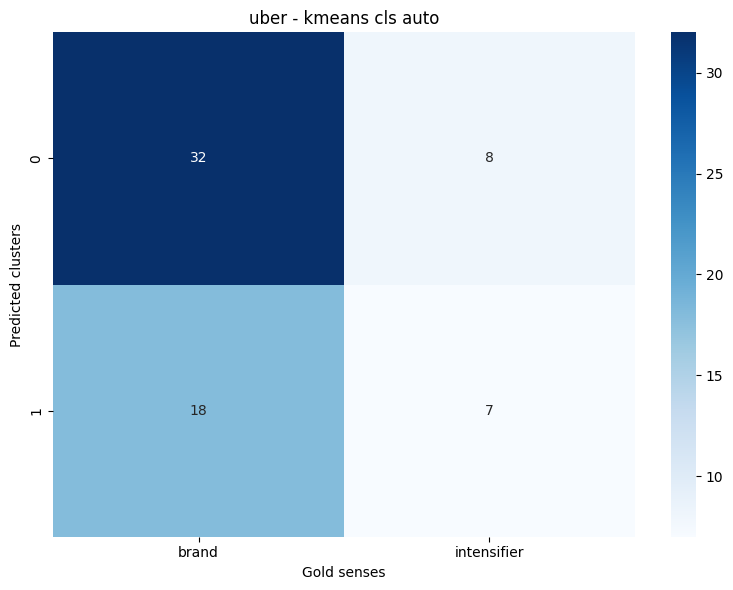

Dominant gold sense per cluster: {0: 'brand', 1: 'brand'}


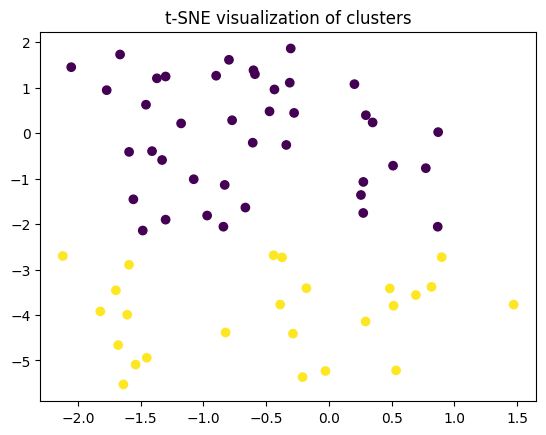

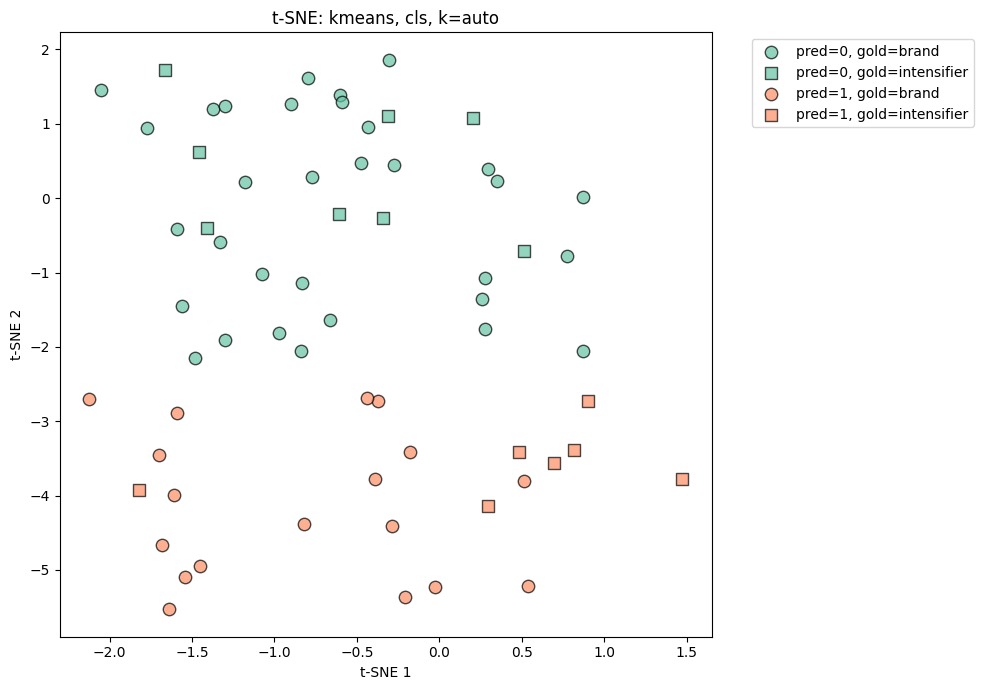


 misclassified examples

text: i have never posted on the theme of before but i must confess is probably the closest it is going to get on insta always dressed totally fabulous and so much fun to work with on our christmas party she is also [MASK] talented at making vibrant jewellery and sells awesome vintage clothes such as the jumpsuit i am wearing in this photo give us a like and follow her page if you want to look this ace too
gold: intensifier pred: 1

text: now pouring on our draught all for one hazy ipa abv a big juicy hazy american ipa brewed in collaboration with megan stone this juicy [MASK] hoppy beer is double dry hopped with citra motueka cascade giving it powerful american muscle flavours of passionfruit grapefruit citrus tropical fruits brewed as part of all for one one for all diversity campaign enjoy it
gold: intensifier pred: 1

text: highly recommend pregaming with [MASK] eats
gold: brand pred: 0

text: truly an icon but about to disappear the one and only london bl

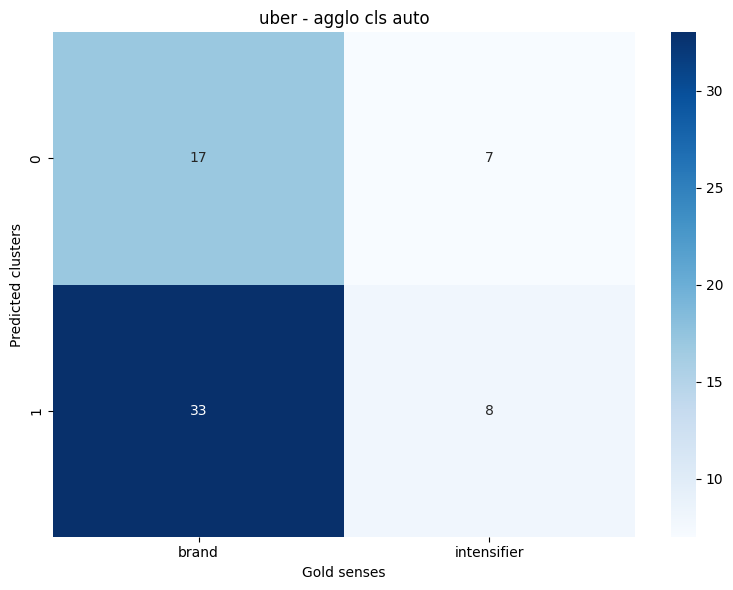

Dominant gold sense per cluster: {0: 'brand', 1: 'brand'}


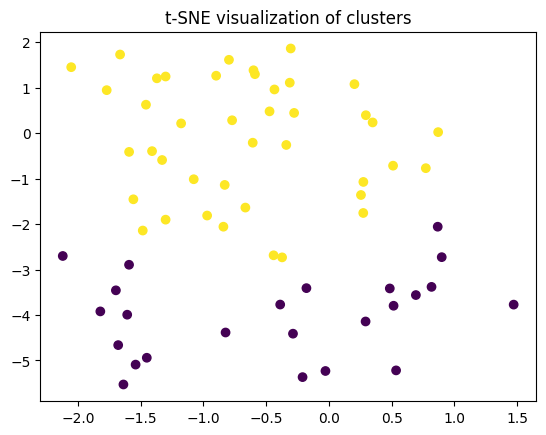

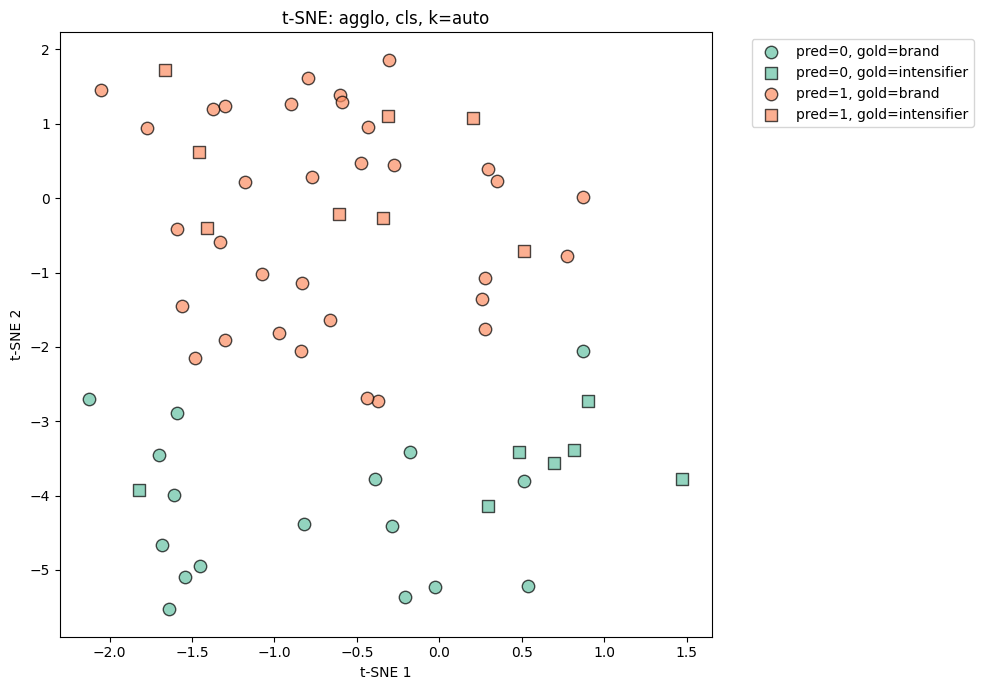


 misclassified examples

text: i have never posted on the theme of before but i must confess is probably the closest it is going to get on insta always dressed totally fabulous and so much fun to work with on our christmas party she is also [MASK] talented at making vibrant jewellery and sells awesome vintage clothes such as the jumpsuit i am wearing in this photo give us a like and follow her page if you want to look this ace too
gold: intensifier pred: 0

text: now pouring on our draught all for one hazy ipa abv a big juicy hazy american ipa brewed in collaboration with megan stone this juicy [MASK] hoppy beer is double dry hopped with citra motueka cascade giving it powerful american muscle flavours of passionfruit grapefruit citrus tropical fruits brewed as part of all for one one for all diversity campaign enjoy it
gold: intensifier pred: 0

text: highly recommend pregaming with [MASK] eats
gold: brand pred: 1

text: truly an icon but about to disappear the one and only london bl

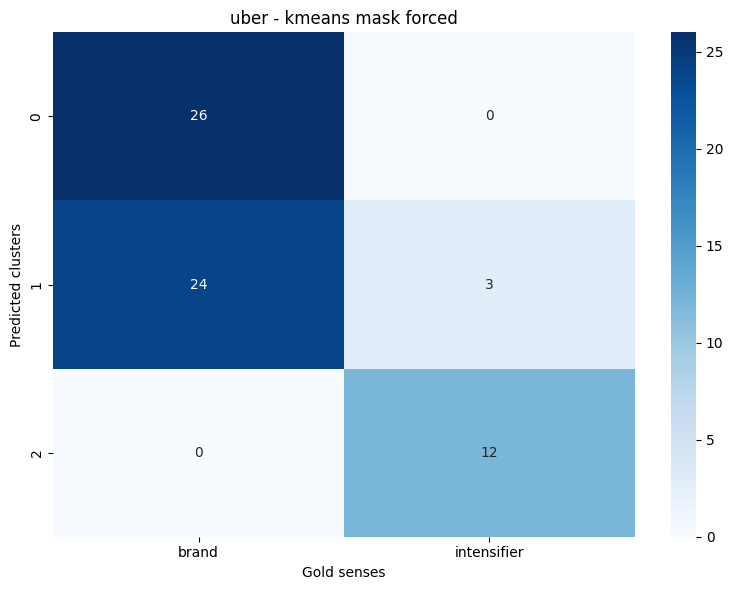

Dominant gold sense per cluster: {0: 'brand', 1: 'brand', 2: 'intensifier'}


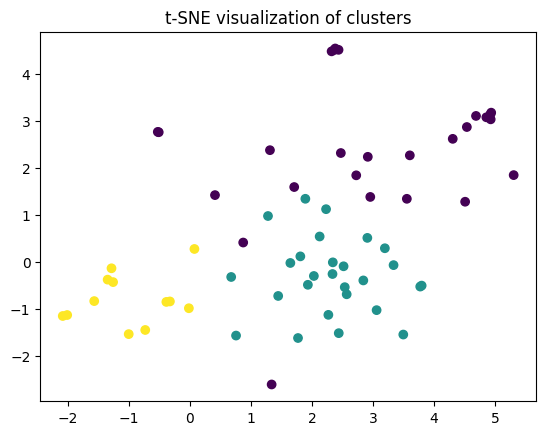

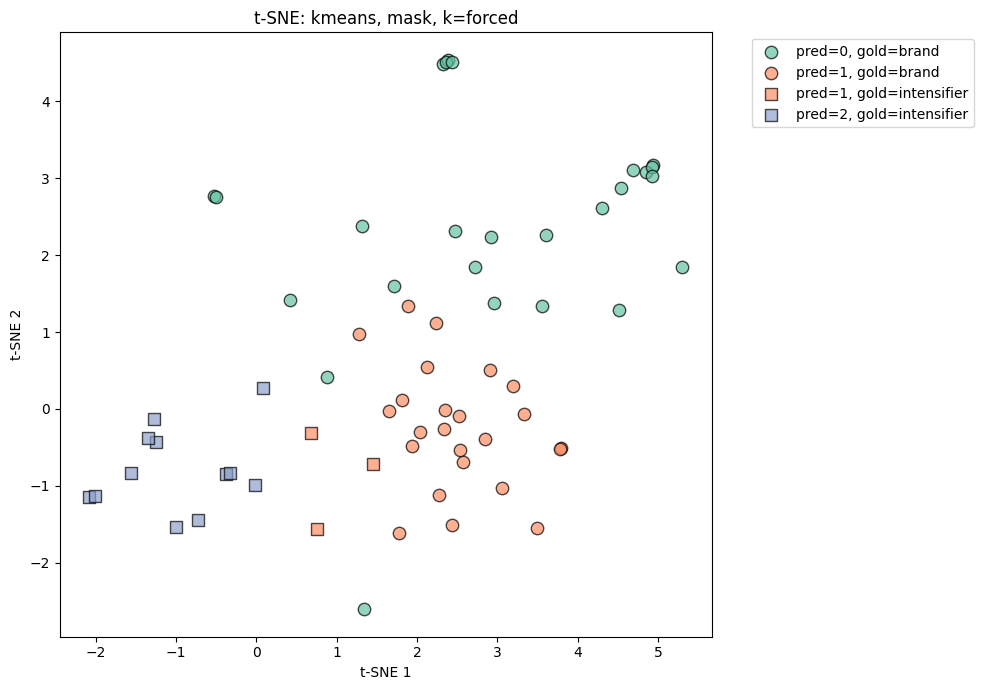


 misclassified examples

text: i have never posted on the theme of before but i must confess is probably the closest it is going to get on insta always dressed totally fabulous and so much fun to work with on our christmas party she is also [MASK] talented at making vibrant jewellery and sells awesome vintage clothes such as the jumpsuit i am wearing in this photo give us a like and follow her page if you want to look this ace too
gold: intensifier pred: 2

text: now pouring on our draught all for one hazy ipa abv a big juicy hazy american ipa brewed in collaboration with megan stone this juicy [MASK] hoppy beer is double dry hopped with citra motueka cascade giving it powerful american muscle flavours of passionfruit grapefruit citrus tropical fruits brewed as part of all for one one for all diversity campaign enjoy it
gold: intensifier pred: 1

text: highly recommend pregaming with [MASK] eats
gold: brand pred: 1

text: truly an icon but about to disappear the one and only london bl

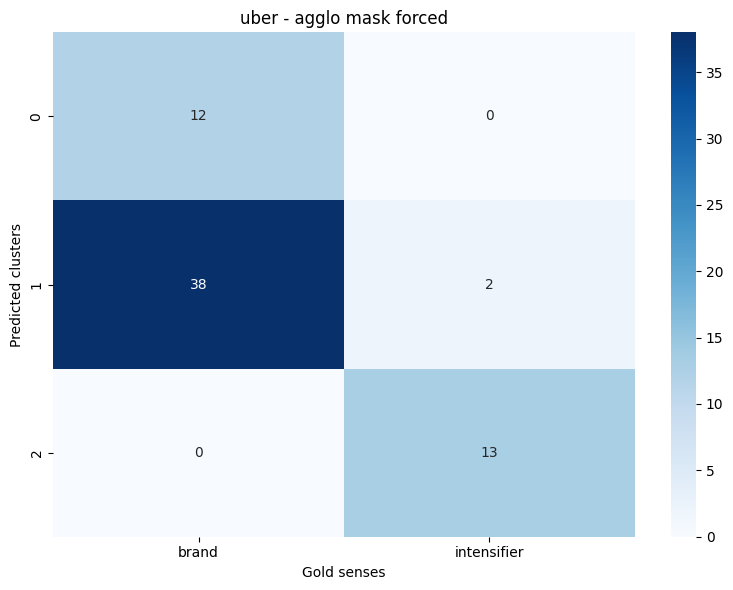

Dominant gold sense per cluster: {0: 'brand', 1: 'brand', 2: 'intensifier'}


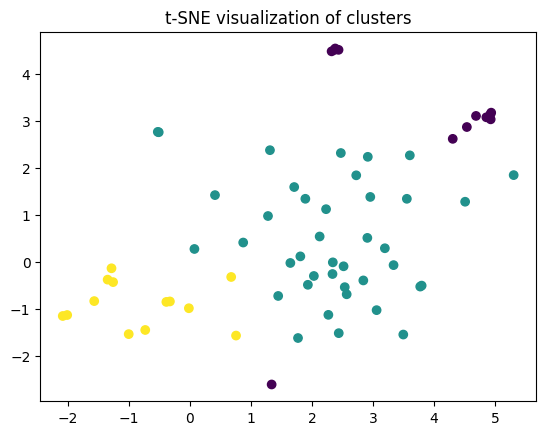

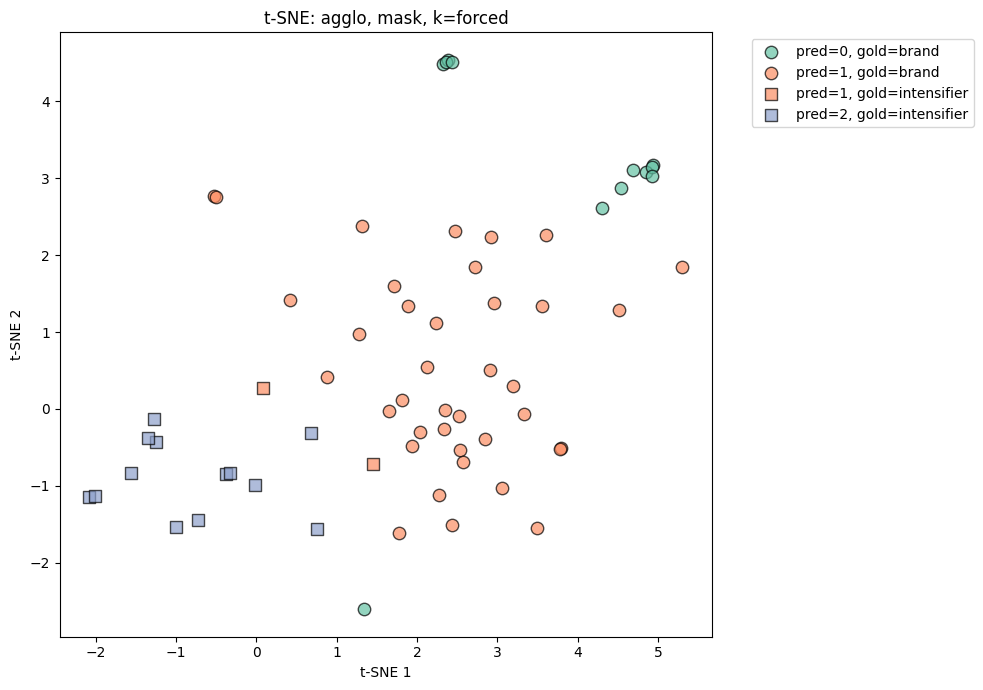


 misclassified examples

text: i have never posted on the theme of before but i must confess is probably the closest it is going to get on insta always dressed totally fabulous and so much fun to work with on our christmas party she is also [MASK] talented at making vibrant jewellery and sells awesome vintage clothes such as the jumpsuit i am wearing in this photo give us a like and follow her page if you want to look this ace too
gold: intensifier pred: 2

text: now pouring on our draught all for one hazy ipa abv a big juicy hazy american ipa brewed in collaboration with megan stone this juicy [MASK] hoppy beer is double dry hopped with citra motueka cascade giving it powerful american muscle flavours of passionfruit grapefruit citrus tropical fruits brewed as part of all for one one for all diversity campaign enjoy it
gold: intensifier pred: 2

text: highly recommend pregaming with [MASK] eats
gold: brand pred: 1

text: truly an icon but about to disappear the one and only london bl

KeyError: 'original_texts'

In [ ]:
terms = ["uber"]

all_results = []


for term in terms:
    print("term:", term)

    df = pd.read_csv(f"data/{term}_annotation.csv")

    configs = [
    # RANDOM BASELINE
    ("random", "mask", "fixed", 3),

    # SIMPLE BASELINE (1 cluster)
    ("baseline", "mask", "fixed", 1),

    # TF-IDF baseline (НОВЫЙ)
    ("kmeans", "tfidf", "auto", None),

    # MAIN MODELS
    ("kmeans", "mask", "auto", None),
    ("agglo", "mask", "auto", None),

    ("kmeans", "cls", "auto", None),
    ("agglo", "cls", "auto", None),

    # FIXED K
    ("kmeans", "mask", "forced", 3),
    ("agglo", "mask", "forced", 3),
]

    for method, emb, k_mode, k in configs:

        print(f"\n {method} | {emb} | {k_mode}")

        res = run_pipeline(
            df,
            tokenizer,
            encoder_model,
            device,
            method=method,
            embedding_type=emb,
            k_mode=k_mode,
            forced_k=k
        )
        plot_confusion_matrix(res, title=f"{term} - {method} {emb} {k_mode}")
        plot_tsne(res["X"], res["labels"])

        plot_tsne_with_shapes(
            X=res["X"],
            pred_labels=res["labels"],
            gold_labels=res["gold"],
            title=f"t-SNE: {method}, {emb}, k={k_mode}"
        )

        show_mismatches(
            res["texts"],
            res["gold"],
            res["labels"]
        )

        print(res["metrics"])

        row = res["metrics"].copy()
        row["method"] = method
        row["embedding"] = emb
        all_results.append(row)


        if method in ["kmeans", "agglo", "hybrid"]:
            show_clusters(
                res["texts"],
                res["labels"],
                res["gold"]
            )


    print("\n CLUSTER-LEVEL SYNONYMS")

    clusters = {}
    for text, label in zip(res["original_texts"], res["labels"]):
        clusters.setdefault(label, []).append(text)

    for cluster_id, texts_cluster in clusters.items():
        freq_syns = cluster_synonyms_freq(texts_cluster, term, tokenizer, mlm_model, device)
        logit_syns = cluster_synonyms_logits(texts_cluster, term, tokenizer, mlm_model, device)

        print("Logits:", logit_syns)


df_results = pd.DataFrame(all_results)
df_results.to_csv("results/results.csv", index=False)

print("\n final results:")
print(df_results)